Modeller inşa ediliyor ve ağırlıklar yükleniyor...
Ağırlıklar başarıyla yüklendi! ✅
'/home/fotas/data/segment/2023.06.04/record_CIFTLIK_SESSIZ_202306040006_30min_raw.bin.hdf5' dosyasından 137 kanalı okunuyor...
Sessiz saha stili analiz ediliyor ve yürüme sentezleniyor...


I0000 00:00:1779260198.803549   64795 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_2426081__.3


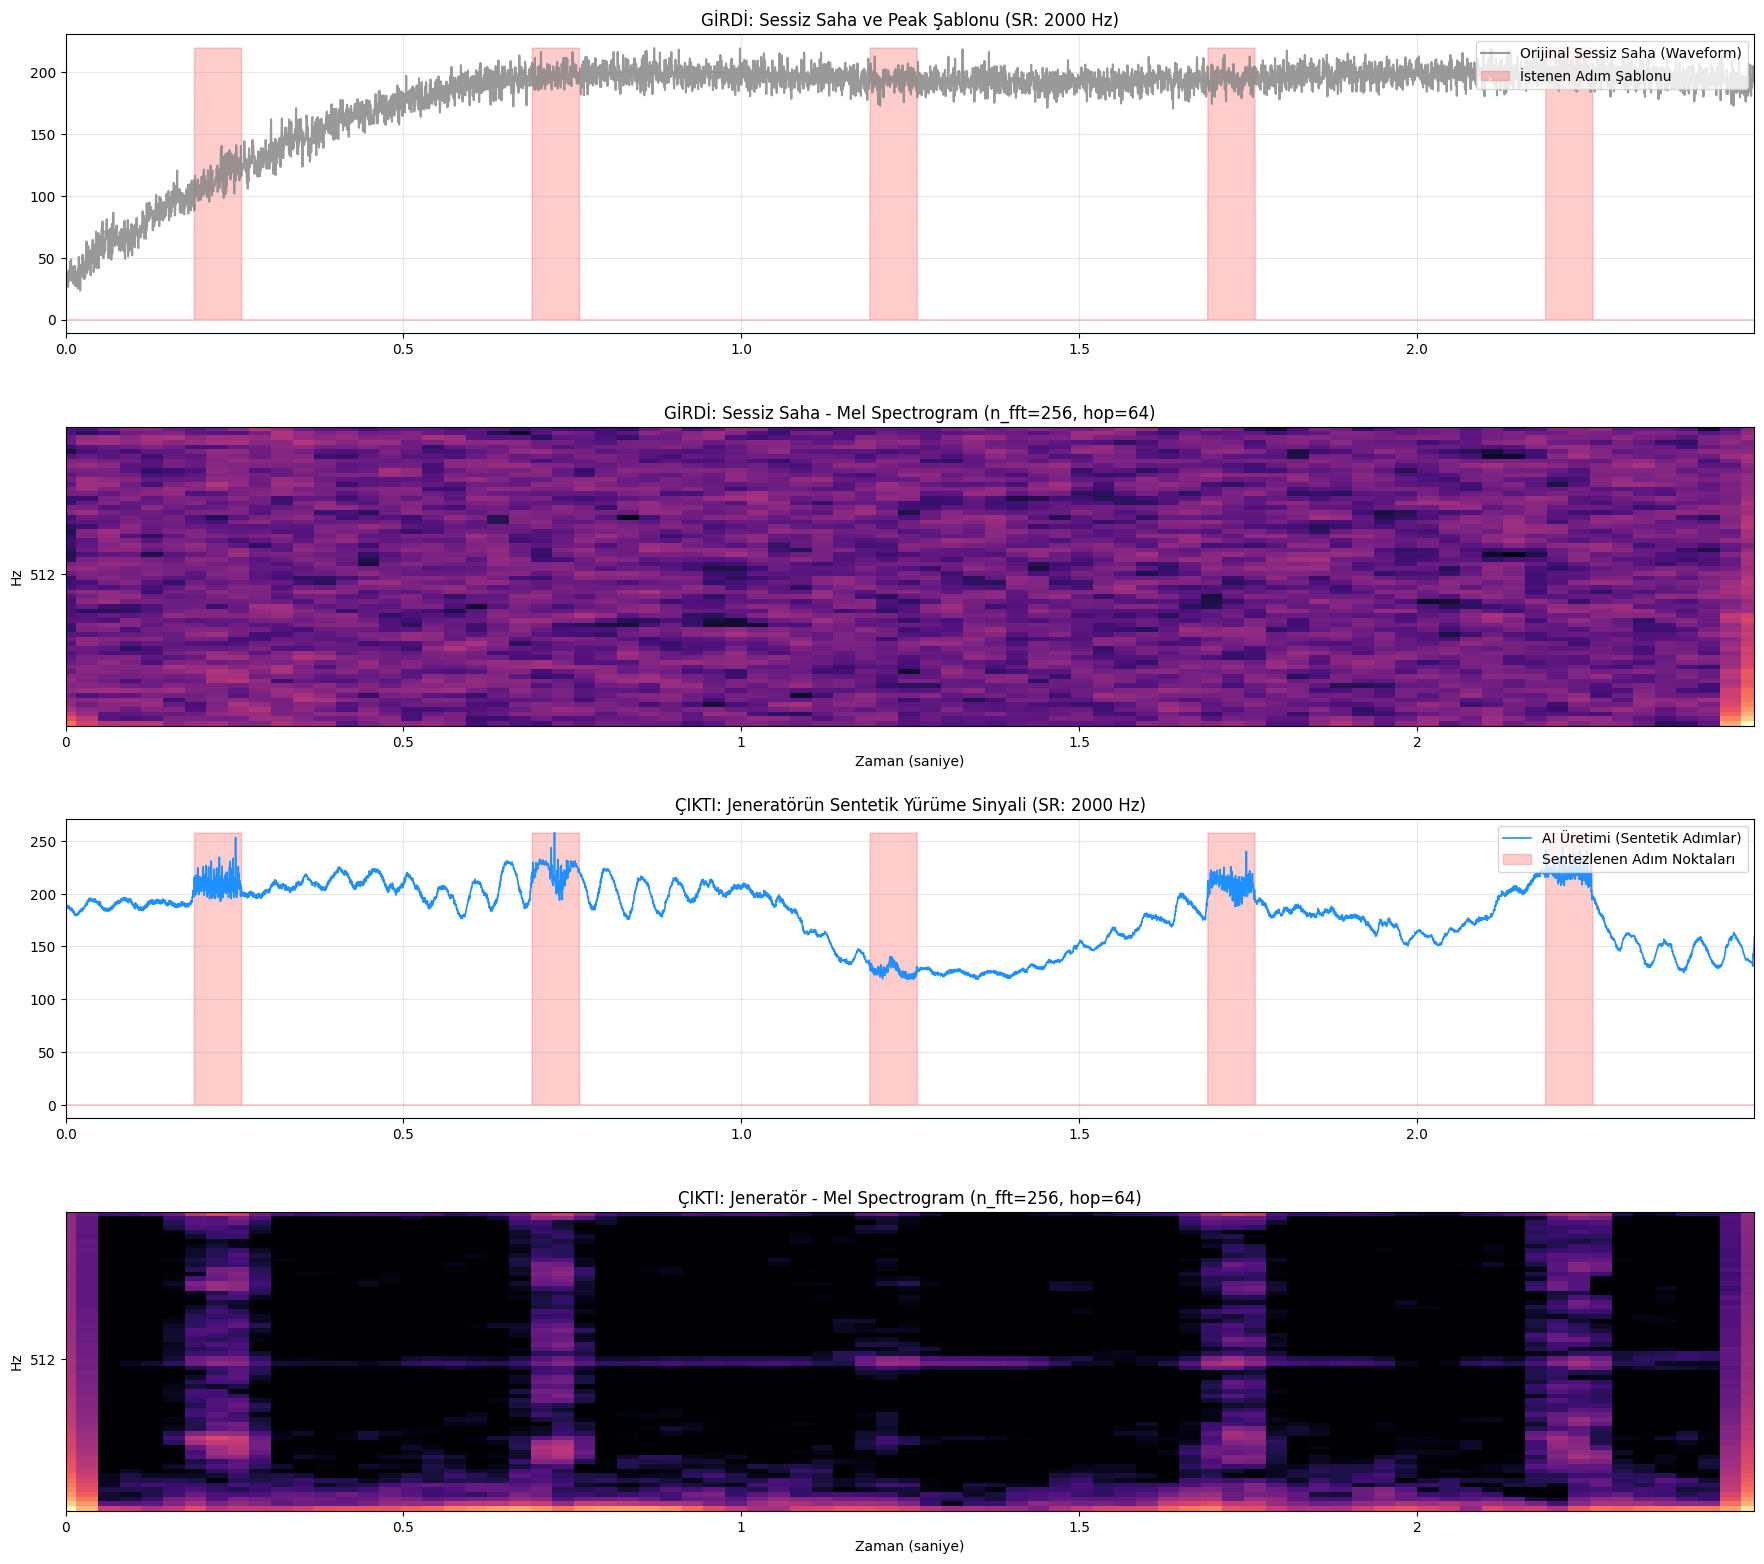

In [10]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import h5py
import librosa
import librosa.display
from timesnet_encoder import TimesBlock
from sequences_peaks import _wavelet_filter
from scipy import signal
from diffusion_encoder import build_conditional_unet_1d
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)
def _slice_or_pad_signal(s, window_size=5000):
    if len(s) > window_size:
        return s[:window_size]
    elif len(s) < window_size:
        return np.pad(s, (0, window_size - len(s)), mode='constant')
    return s

# --- 1. GİRDİ PARAMETRELERİ (KENDİNE GÖRE DÜZENLE) ---
MODEL_FOLDER = "20260518-DiffGAN-v4.7.1"
GEN_MODEL_FOLDER = "20260514-GAN-v4.6.4.1"
ENC_WEIGHT_PATH = os.path.join(MODEL_FOLDER, "weights", "encoder_epoch_500.weights.h5")
GEN_WEIGHT_PATH = os.path.join(GEN_MODEL_FOLDER, "weights", "generator_epoch_140.weights.h5")

SESSİZ_DATA_PATH = "/home/fotas/data/segment/2023.06.04/record_CIFTLIK_SESSIZ_202306040006_30min_raw.bin.hdf5"
CHANNEL = "137" 
WINDOW_START = 0
WINDOW_SIZE = 5000
WINDOW_END = WINDOW_START + WINDOW_SIZE
SAMPLE_RATE = 2000 # DAS cihazının örnekleme frekansı
# ---------------------------------------------------

# --- 2. MODELLERİ İNŞA ET VE AĞIRLIKLARI YÜKLE ---
print("Modeller inşa ediliyor ve ağırlıklar yükleniyor...")
encoder = TimesBlock.build_encoder_v4(window=WINDOW_SIZE, latent_dim=128)
generator = TimesBlock.build_generator_v4(window=WINDOW_SIZE, latent_dim=128)

encoder.load_weights(ENC_WEIGHT_PATH)
generator.load_weights(GEN_WEIGHT_PATH)
print("Ağırlıklar başarıyla yüklendi! ✅")

# --- 3. SESSİZ DATAYI OKU ---
print(f"'{SESSİZ_DATA_PATH}' dosyasından {CHANNEL} kanalı okunuyor...")
with h5py.File(SESSİZ_DATA_PATH, "r") as f:
    s = f[CHANNEL][:]["P"]

    if s.dtype.names and "re" in s.dtype.names and "im" in s.dtype.names:
        s_re = s["re"][WINDOW_START:WINDOW_END]
        s_im = s["im"][WINDOW_START:WINDOW_END]
        sessiz_ham = np.hypot(s_re, s_im)
    else:
        sessiz_ham = s[WINDOW_START:WINDOW_END]
        
    sessiz_ham = _slice_or_pad_signal(sessiz_ham, WINDOW_SIZE)

sessiz_ham = sessiz_ham.reshape(1, WINDOW_SIZE, 1).astype(np.float32)

# --- 4. PEAK MASKESİNİ HAZIRLA ---
peak_mask = np.zeros((1, WINDOW_SIZE, 1), dtype=np.float32)
adim_noktalari = [1500, 3500, 4500, 2500, 500] 
for nokta in adim_noktalari:
    peak_mask[0, nokta-120:nokta+20, 0] = 1.0 # 40 birimlik rastgele genişlik simülasyonu

# --- 5. Z-SCORE NORMALİZASYONU ---
mean = np.mean(sessiz_ham, axis=1, keepdims=True)
std = np.std(sessiz_ham, axis=1, keepdims=True) + 1e-8
sessiz_norm = (sessiz_ham - mean) / std

# --- 6. INFERENCE (SENTEZLEME) ---
print("Sessiz saha stili analiz ediliyor ve yürüme sentezleniyor...")
encoder_input = tf.concat([sessiz_norm, peak_mask], axis=-1)
z_encoded = encoder.predict(encoder_input, verbose=0)

fake_yurume_norm = generator.predict([z_encoded, peak_mask], verbose=0)

# Üretilen veriyi orijinal fiziksel genliğine geri getir
fake_yurume_orijinal = (fake_yurume_norm * std) + mean

# --- 7. VİTRİN / 4 PANELLİ GÖRSELLEŞTİRME ---
sessiz_1d = sessiz_ham[0, :, 0]
fake_1d = fake_yurume_orijinal[0, :, 0]
mask_1d = peak_mask[0, :, 0]

# # a. Detrend (Eksen kaymasını sil - İkisine de uygulanmalı)
# sessiz_1d = signal.detrend(sessiz_1d)
# fake_1d = signal.detrend(fake_1d)

# # b. High-Pass Filter (DC Offset / 0Hz gürültüsünü sil - İkisine de uygulanmalı)
# sos = signal.butter(4, 5, 'hp', fs=SAMPLE_RATE, output='sos') 
# sessiz_1d = signal.sosfiltfilt(sos, sessiz_1d)
# fake_1d = signal.sosfiltfilt(sos, fake_1d)

# # c. Wavelet Denoise (İsteğe bağlı pürüzsüzleştirme)
# sessiz_denoised = _wavelet_filter(sessiz_1d)
# fake_denoised = _wavelet_filter(fake_1d)

# +++ ZAMAN EKSENİ OLUŞTURMA (SANİYE BAZLI) +++
time_axis = np.arange(WINDOW_SIZE) / SAMPLE_RATE
max_time = time_axis[-1]

# --- SPEKTROGRAM AYARLARI (SR=2000 için optimize edildi) ---
HOP_LENGTH = 64   
N_FFT = 256       
FMIN = 10         
FMAX = 1000       
DB_MIN = -50      

plt.figure(figsize=(18, 16), dpi=100)

# 1. PANEL: Girdi Waveform (HAM)
plt.subplot(4, 1, 1)
# X ekseni olarak "time_axis" verildi
plt.plot(time_axis, sessiz_1d, color='gray', alpha=0.8, label="Orijinal Sessiz Saha (Waveform)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(sessiz_1d)), color='red', alpha=0.2, label="İstenen Adım Şablonu")
plt.xlim([0, max_time]) # Tam hizalama sınırı
plt.title(f"GİRDİ: Sessiz Saha ve Peak Şablonu (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 2. PANEL: Girdi Mel Spectrogram
ax2 = plt.subplot(4, 1, 2)
S_sessiz = librosa.feature.melspectrogram(y=sessiz_1d, sr=SAMPLE_RATE, n_mels=64, 
                                          n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_sessiz_db = librosa.power_to_db(S_sessiz, ref=np.max)
img_sessiz = librosa.display.specshow(S_sessiz_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                      ax=ax2, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                      cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) # Tam hizalama sınırı
plt.title(f"GİRDİ: Sessiz Saha - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Zaman (saniye)")

# 3. PANEL: Çıktı Waveform (HAM)
plt.subplot(4, 1, 3)
# X ekseni olarak "time_axis" verildi
plt.plot(time_axis, fake_1d, color='dodgerblue', linewidth=1.2, label="AI Üretimi (Sentetik Adımlar)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(fake_1d)), color='red', alpha=0.2, label="Sentezlenen Adım Noktaları")
plt.xlim([0, max_time]) # Tam hizalama sınırı
plt.title(f"ÇIKTI: Jeneratörün Sentetik Yürüme Sinyali (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 4. PANEL: Çıktı Mel Spectrogram
ax4 = plt.subplot(4, 1, 4)
S_fake = librosa.feature.melspectrogram(y=fake_1d, sr=SAMPLE_RATE, n_mels=64, 
                                        n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_fake_db = librosa.power_to_db(S_fake, ref=np.max)
img_fake = librosa.display.specshow(S_fake_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                    ax=ax4, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                    cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) # Tam hizalama sınırı
plt.title(f"ÇIKTI: Jeneratör - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Zaman (saniye)")

plt.tight_layout(pad=2.0)
plt.show()

Modeller inşa ediliyor ve ağırlıklar yükleniyor...
Ağırlıklar başarıyla yüklendi! ✅
'/home/fotas/data/segment/2023.06.04/record_CIFTLIK_SESSIZ_202306040006_30min_raw.bin.hdf5' dosyasından 137 kanalı okunuyor...
Sessiz saha stili analiz ediliyor...

Difüzyon Modeli yürüme sinyalini sentezliyor (1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:47<00:00,  4.39it/s]


Sentezleme Başarılı! ✅



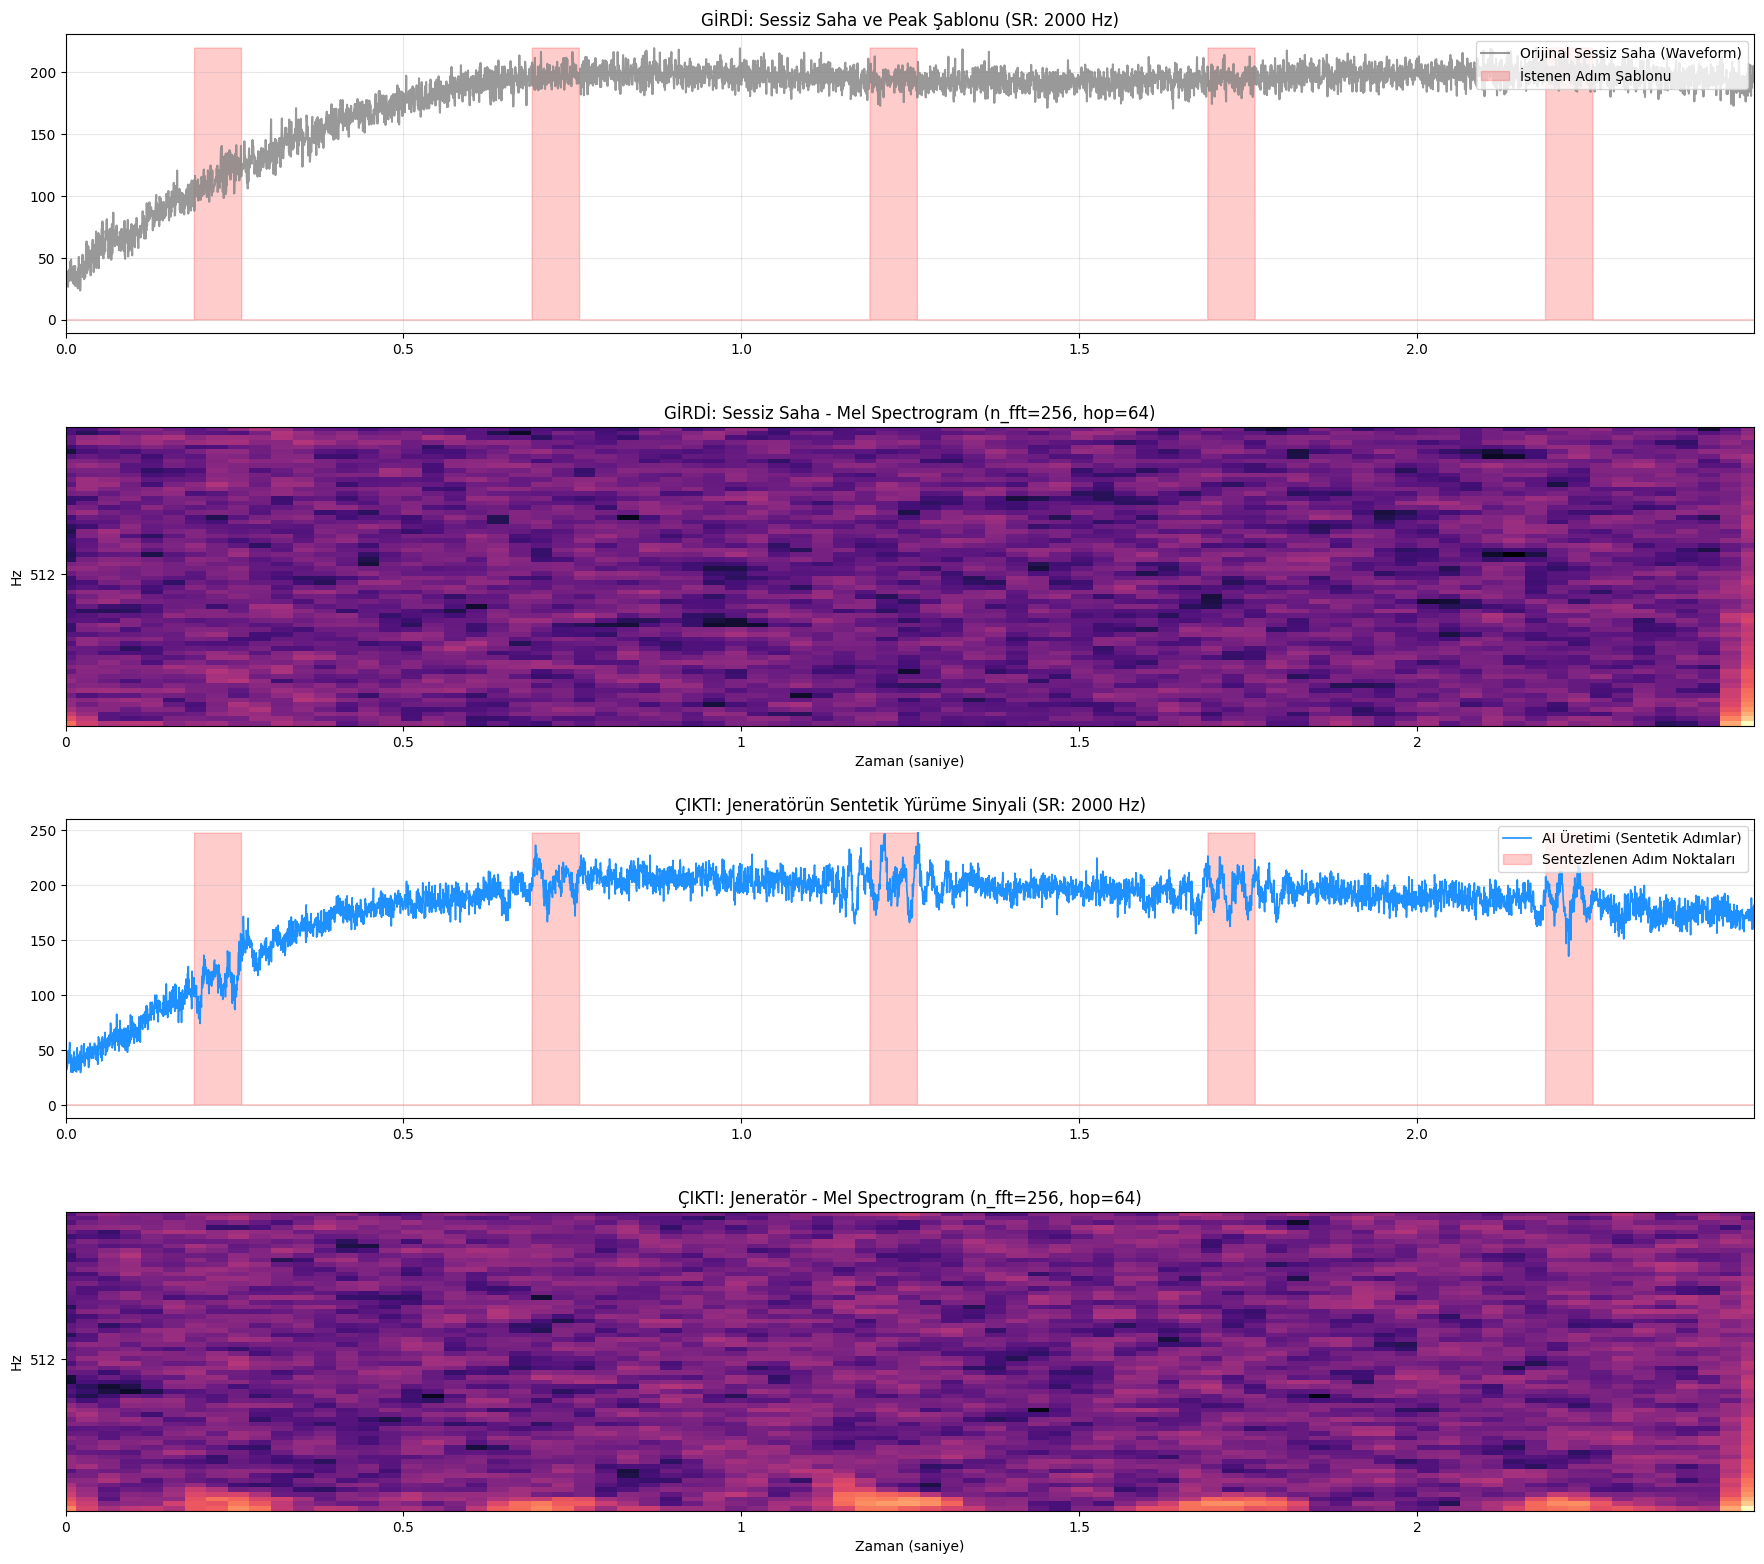

In [6]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import h5py
import librosa
import librosa.display
from timesnet_encoder import TimesBlock
from sequences_peaks import _wavelet_filter
from scipy import signal
from diffusion_encoder import build_conditional_unet_1d
from tqdm import tqdm  # +++ YENİ: İlerleme çubuğu için eklendi +++
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)
def _slice_or_pad_signal(s, window_size=5000):
    if len(s) > window_size:
        return s[:window_size]
    elif len(s) < window_size:
        return np.pad(s, (0, window_size - len(s)), mode='constant')
    return s

# --- 1. GİRDİ PARAMETRELERİ (KENDİNE GÖRE DÜZENLE) ---
MODEL_FOLDER = "20260518-DiffGAN-v4.7.1"
ENC_WEIGHT_PATH = os.path.join(MODEL_FOLDER, "weights", "encoder_epoch_500.weights.h5")
GEN_WEIGHT_PATH = os.path.join(MODEL_FOLDER, "weights", "diffusion_unet_epoch_500.weights.h5")

SESSİZ_DATA_PATH = "/home/fotas/data/segment/2023.06.04/record_CIFTLIK_SESSIZ_202306040006_30min_raw.bin.hdf5"
CHANNEL = "137" 
WINDOW_START = 0
WINDOW_SIZE = 5000
WINDOW_END = WINDOW_START + WINDOW_SIZE
SAMPLE_RATE = 2000 # DAS cihazının örnekleme frekansı
# ---------------------------------------------------

# --- 2. MODELLERİ İNŞA ET VE AĞIRLIKLARI YÜKLE ---
print("Modeller inşa ediliyor ve ağırlıklar yükleniyor...")
encoder = TimesBlock.build_encoder_v4(window=WINDOW_SIZE, latent_dim=128)
diffusion_unet = build_conditional_unet_1d(window=WINDOW_SIZE, latent_dim=128) # generator ismi diffusion_unet oldu

encoder.load_weights(ENC_WEIGHT_PATH)
diffusion_unet.load_weights(GEN_WEIGHT_PATH)
print("Ağırlıklar başarıyla yüklendi! ✅")

# --- 3. SESSİZ DATAYI OKU ---
print(f"'{SESSİZ_DATA_PATH}' dosyasından {CHANNEL} kanalı okunuyor...")
with h5py.File(SESSİZ_DATA_PATH, "r") as f:
    s = f[CHANNEL][:]["P"]

    if s.dtype.names and "re" in s.dtype.names and "im" in s.dtype.names:
        s_re = s["re"][WINDOW_START:WINDOW_END]
        s_im = s["im"][WINDOW_START:WINDOW_END]
        sessiz_ham = np.hypot(s_re, s_im)
    else:
        sessiz_ham = s[WINDOW_START:WINDOW_END]
        
    sessiz_ham = _slice_or_pad_signal(sessiz_ham, WINDOW_SIZE)

sessiz_ham = sessiz_ham.reshape(1, WINDOW_SIZE, 1).astype(np.float32)

# --- 4. PEAK MASKESİNİ HAZIRLA ---
peak_mask = np.zeros((1, WINDOW_SIZE, 1), dtype=np.float32)
adim_noktalari = [1500, 3500, 4500, 2500, 500] 
for nokta in adim_noktalari:
    peak_mask[0, nokta-120:nokta+20, 0] = 1.0 # 40 birimlik rastgele genişlik simülasyonu
peak_mask_tf = tf.convert_to_tensor(peak_mask, dtype=tf.float32)

# --- 5. Z-SCORE NORMALİZASYONU ---
mean = np.mean(sessiz_ham, axis=1, keepdims=True)
std = np.std(sessiz_ham, axis=1, keepdims=True) + 1e-8
sessiz_norm = (sessiz_ham - mean) / std

# --- 6. INFERENCE (DİFÜZYON İLE SENTEZLEME) ---
print("Sessiz saha stili analiz ediliyor...")
encoder_input = tf.concat([sessiz_norm, peak_mask], axis=-1)
z_encoded_numpy = encoder.predict(encoder_input, verbose=0)
z_encoded = tf.convert_to_tensor(z_encoded_numpy, dtype=tf.float32)
print("\nDifüzyon Modeli yürüme sinyalini sentezliyor (1000 Adım)...")

# +++ DİFÜZYON TAKVİMİ VE DÖNGÜSÜ +++
T = 1000
betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas)

# Saf beyaz gürültüden (mermer bloğu) başla
x = tf.random.normal(shape=(1, WINDOW_SIZE, 1))

# T'den 0'a doğru adım adım yont
for t in tqdm(reversed(range(T)), total=T, desc="Denoising"):
    t_normalized = tf.ones((1, 1), dtype=tf.float32) * (t / float(T))
    
    # U-Net'ten gürültüyü tahmin etmesini iste
    pred_noise = diffusion_unet([x, t_normalized, z_encoded, peak_mask_tf], training=False)
    
    alpha_t = alphas[t]
    alpha_t_cumprod = alphas_cumprod[t]
    beta_t = betas[t]
    
    # Son adım hariç ekstra gürültü ekle (Langevin Dynamics)
    if t > 0:
        noise = tf.random.normal(shape=tf.shape(x))
    else:
        noise = tf.zeros_like(x)
        
    # DDPM Güncelleme Formülü
    x = (1.0 / np.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / np.sqrt(1.0 - alpha_t_cumprod)) * pred_noise) + np.sqrt(beta_t) * noise

fake_yurume_norm = x.numpy()

# Üretilen veriyi orijinal fiziksel genliğine geri getir
fake_yurume_orijinal = (fake_yurume_norm * std) + mean
print("Sentezleme Başarılı! ✅\n")

# --- 7. VİTRİN / 4 PANELLİ GÖRSELLEŞTİRME ---
sessiz_1d = sessiz_ham[0, :, 0]
fake_1d = fake_yurume_orijinal[0, :, 0]
mask_1d = peak_mask[0, :, 0]

# +++ ZAMAN EKSENİ OLUŞTURMA (SANİYE BAZLI) +++
time_axis = np.arange(WINDOW_SIZE) / SAMPLE_RATE
max_time = time_axis[-1]

# --- SPEKTROGRAM AYARLARI (SR=2000 için optimize edildi) ---
HOP_LENGTH = 64   
N_FFT = 256       
FMIN = 10         
FMAX = 1000       
DB_MIN = -50      

plt.figure(figsize=(18, 16), dpi=100)

# 1. PANEL: Girdi Waveform (HAM)
plt.subplot(4, 1, 1)
plt.plot(time_axis, sessiz_1d, color='gray', alpha=0.8, label="Orijinal Sessiz Saha (Waveform)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(sessiz_1d)), color='red', alpha=0.2, label="İstenen Adım Şablonu")
plt.xlim([0, max_time]) 
plt.title(f"GİRDİ: Sessiz Saha ve Peak Şablonu (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 2. PANEL: Girdi Mel Spectrogram
ax2 = plt.subplot(4, 1, 2)
S_sessiz = librosa.feature.melspectrogram(y=sessiz_1d, sr=SAMPLE_RATE, n_mels=64, 
                                          n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_sessiz_db = librosa.power_to_db(S_sessiz, ref=np.max)
img_sessiz = librosa.display.specshow(S_sessiz_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                      ax=ax2, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                      cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) 
plt.title(f"GİRDİ: Sessiz Saha - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Zaman (saniye)")

# 3. PANEL: Çıktı Waveform (HAM)
plt.subplot(4, 1, 3)
plt.plot(time_axis, fake_1d, color='dodgerblue', linewidth=1.2, label="AI Üretimi (Sentetik Adımlar)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(fake_1d)), color='red', alpha=0.2, label="Sentezlenen Adım Noktaları")
plt.xlim([0, max_time]) 
plt.title(f"ÇIKTI: Jeneratörün Sentetik Yürüme Sinyali (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 4. PANEL: Çıktı Mel Spectrogram
ax4 = plt.subplot(4, 1, 4)
S_fake = librosa.feature.melspectrogram(y=fake_1d, sr=SAMPLE_RATE, n_mels=64, 
                                        n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_fake_db = librosa.power_to_db(S_fake, ref=np.max)
img_fake = librosa.display.specshow(S_fake_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                    ax=ax4, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                    cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) 
plt.title(f"ÇIKTI: Jeneratör - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Zaman (saniye)")

plt.tight_layout(pad=2.0)
plt.show()

Wavelet filtresi uygulanıyor, ikinci pencere hazırlanıyor...


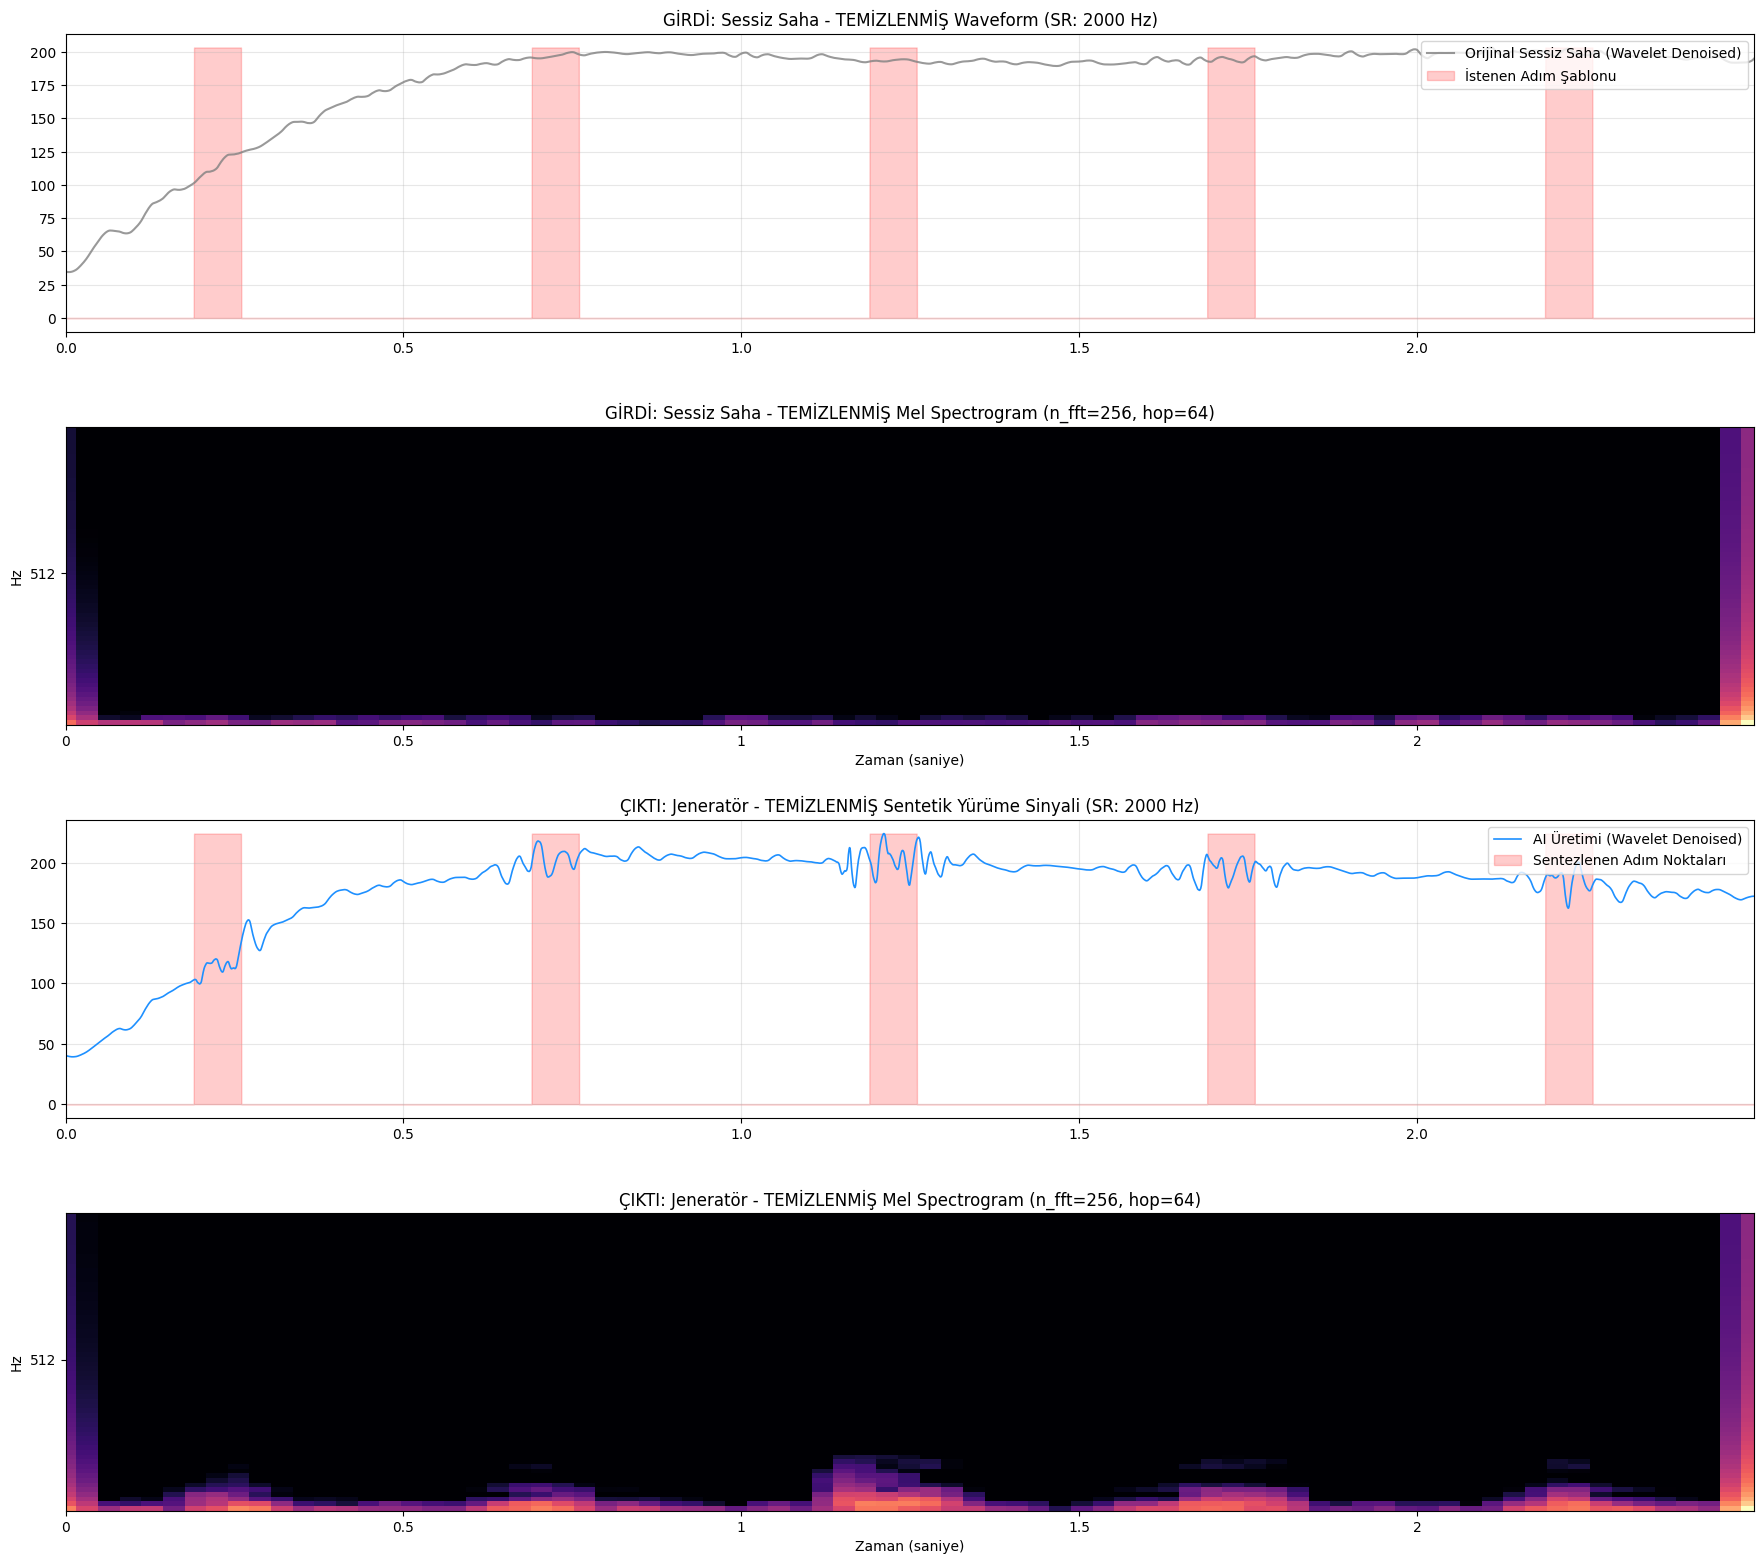

In [7]:
# ====================================================================
# --- 8. VİTRİN: WAVELET İLE TEMİZLENMİŞ (DENOISED) SİNYALLER ---
# ====================================================================
print("Wavelet filtresi uygulanıyor, ikinci pencere hazırlanıyor...")

# Wavelet Denoising İşlemi (Yorumdan çıkardık)
sessiz_denoised = _wavelet_filter(sessiz_1d)
fake_denoised = _wavelet_filter(fake_1d)

# İKİNCİ PENCERE AÇILIYOR
plt.figure(figsize=(18, 16), dpi=100)

# 1. PANEL: Girdi Waveform (DENOISED)
plt.subplot(4, 1, 1)
plt.plot(time_axis, sessiz_denoised, color='gray', alpha=0.8, label="Orijinal Sessiz Saha (Wavelet Denoised)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(sessiz_denoised)), color='red', alpha=0.2, label="İstenen Adım Şablonu")
plt.xlim([0, max_time]) 
plt.title(f"GİRDİ: Sessiz Saha - TEMİZLENMİŞ Waveform (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 2. PANEL: Girdi Mel Spectrogram (DENOISED)
ax2 = plt.subplot(4, 1, 2)
S_sessiz_den = librosa.feature.melspectrogram(y=sessiz_denoised, sr=SAMPLE_RATE, n_mels=64, 
                                              n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_sessiz_den_db = librosa.power_to_db(S_sessiz_den, ref=np.max)
img_sessiz_den = librosa.display.specshow(S_sessiz_den_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                          ax=ax2, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                          cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) 
plt.title(f"GİRDİ: Sessiz Saha - TEMİZLENMİŞ Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Zaman (saniye)")

# 3. PANEL: Çıktı Waveform (DENOISED)
plt.subplot(4, 1, 3)
plt.plot(time_axis, fake_denoised, color='dodgerblue', linewidth=1.2, label="AI Üretimi (Wavelet Denoised)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(fake_denoised)), color='red', alpha=0.2, label="Sentezlenen Adım Noktaları")
plt.xlim([0, max_time]) 
plt.title(f"ÇIKTI: Jeneratör - TEMİZLENMİŞ Sentetik Yürüme Sinyali (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 4. PANEL: Çıktı Mel Spectrogram (DENOISED)
ax4 = plt.subplot(4, 1, 4)
S_fake_den = librosa.feature.melspectrogram(y=fake_denoised, sr=SAMPLE_RATE, n_mels=64, 
                                            n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_fake_den_db = librosa.power_to_db(S_fake_den, ref=np.max)
img_fake_den = librosa.display.specshow(S_fake_den_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                        ax=ax4, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                        cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) 
plt.title(f"ÇIKTI: Jeneratör - TEMİZLENMİŞ Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Zaman (saniye)")

plt.tight_layout(pad=2.0)
plt.show()

I0000 00:00:1780496483.845471     298 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.



SEED: 85420

Modeller inşa ediliyor ve ağırlıklar yükleniyor...


I0000 00:00:1780496487.267557     298 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21575 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


Ağırlıklar başarıyla yüklendi! ✅
'/home/fotas/data/segment/2023.06.04/record_CIFTLIK_SESSIZ_202306040006_30min_raw.bin.hdf5' dosyasından 137 kanalı okunuyor...
Sessiz saha stili analiz ediliyor...


E0000 00:00:1780496489.385785     298 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
I0000 00:00:1780496489.566082     407 cuda_dnn.cc:461] Loaded cuDNN version 92200



Difüzyon Modeli yürüme sinyalini sentezliyor (1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:49<00:00,  4.36it/s]


Sentezleme Başarılı! ✅



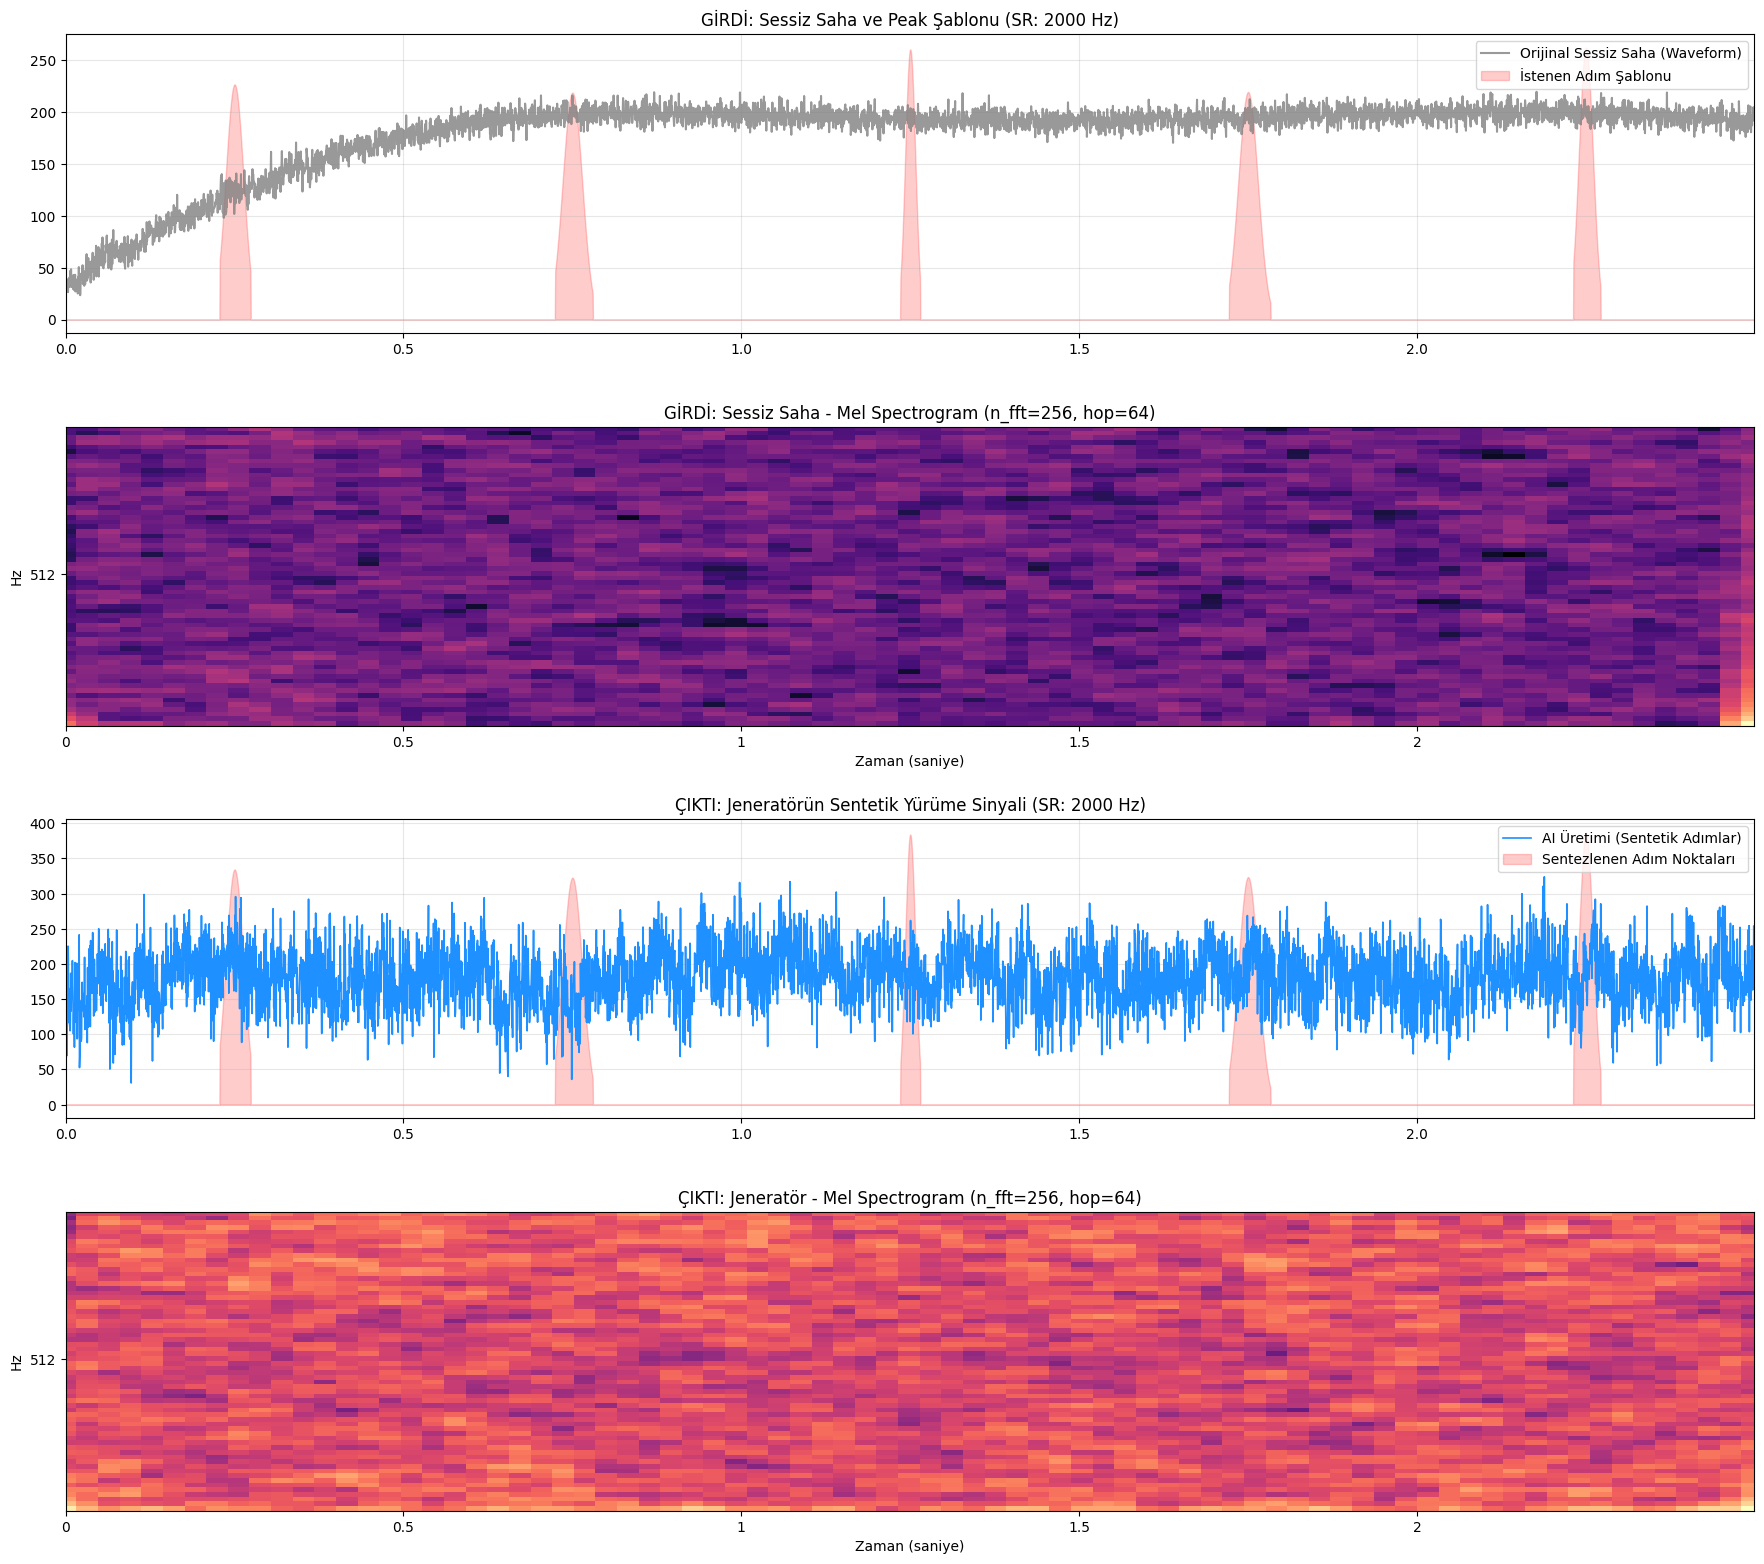

In [1]:
import os
import random
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import h5py
import librosa
import librosa.display
from timesnet_encoder import TimesBlock
from sequences_peaks import _wavelet_filter
from scipy import signal
from diffusion_encoder import build_conditional_unet_1d
from tqdm import tqdm  
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)
# =================================================================
# --- 0. SEED AYARI (TEKRARLANABİLİRLİK İÇİN) ---
# =================================================================
CURRENT_SEED = random.randint(0, 100000)
# Eğer beğendiğin bir sonucu tekrar üretmek istersen üstteki satırı yoruma al ve aşağıdakini kullan:
# CURRENT_SEED = 42871 

print(f"\n{'='*50}")
print(f"SEED: {CURRENT_SEED}")
print(f"{'='*50}\n")

os.environ['PYTHONHASHSEED'] = str(CURRENT_SEED)
random.seed(CURRENT_SEED)
np.random.seed(CURRENT_SEED)
tf.random.set_seed(CURRENT_SEED)
tf.config.experimental.enable_op_determinism()
# =================================================================

def _slice_or_pad_signal(s, window_size=5000):
    if len(s) > window_size:
        return s[:window_size]
    elif len(s) < window_size:
        return np.pad(s, (0, window_size - len(s)), mode='constant')
    return s

# --- 1. GİRDİ PARAMETRELERİ (KENDİNE GÖRE DÜZENLE) ---
MODEL_FOLDER = "20260518-DiffGAN-v4.7.1"
GEN_MODEL_FOLDER = "20260520-DiffGAN-v4.7.2"
ENC_WEIGHT_PATH = os.path.join(MODEL_FOLDER, "weights", "encoder_epoch_500.weights.h5")
GEN_WEIGHT_PATH = os.path.join(GEN_MODEL_FOLDER, "weights", "diffusion_unet_epoch_500.weights.h5")

SESSİZ_DATA_PATH = "/home/fotas/data/segment/2023.06.04/record_CIFTLIK_SESSIZ_202306040006_30min_raw.bin.hdf5"
CHANNEL = "137" 
WINDOW_START = 0
WINDOW_SIZE = 5000
WINDOW_END = WINDOW_START + WINDOW_SIZE
SAMPLE_RATE = 2000 # DAS cihazının örnekleme frekansı
# ---------------------------------------------------

# --- 2. MODELLERİ İNŞA ET VE AĞIRLIKLARI YÜKLE ---
print("Modeller inşa ediliyor ve ağırlıklar yükleniyor...")
encoder = TimesBlock.build_encoder_v4(window=WINDOW_SIZE, latent_dim=128)
diffusion_unet = build_conditional_unet_1d(window=WINDOW_SIZE, latent_dim=128) # generator ismi diffusion_unet oldu

encoder.load_weights(ENC_WEIGHT_PATH)
diffusion_unet.load_weights(GEN_WEIGHT_PATH)
print("Ağırlıklar başarıyla yüklendi! ✅")

# --- 3. SESSİZ DATAYI OKU ---
print(f"'{SESSİZ_DATA_PATH}' dosyasından {CHANNEL} kanalı okunuyor...")
with h5py.File(SESSİZ_DATA_PATH, "r") as f:
    s = f[CHANNEL][:]["P"]

    if s.dtype.names and "re" in s.dtype.names and "im" in s.dtype.names:
        s_re = s["re"][WINDOW_START:WINDOW_END]
        s_im = s["im"][WINDOW_START:WINDOW_END]
        sessiz_ham = np.hypot(s_re, s_im)
    else:
        sessiz_ham = s[WINDOW_START:WINDOW_END]
        
    sessiz_ham = _slice_or_pad_signal(sessiz_ham, WINDOW_SIZE)

sessiz_ham = sessiz_ham.reshape(1, WINDOW_SIZE, 1).astype(np.float32)

# --- 4. PEAK MASKESİNİ HAZIRLA (Rastgele Genişlikli Gaussian Şablonlar) ---
peak_mask = np.zeros((1, WINDOW_SIZE, 1), dtype=np.float32)
adim_noktalari = [1500, 3500, 4500, 2500, 500] 

for p in adim_noktalari:
    # 1. Tamamen rastgele bir genişlik (örneğin toplam 40 ile 120 örnek arası)
    # sr=2000'de bu yaklaşık 0.02 ile 0.06 saniye arası ayak sürtünmesi demektir
    sigma = np.random.randint(20, 60) 
    
    # 2. Asimetrik adım izi (Topuk sert vurur, burun yavaş sürter)
    # Bunu simüle etmek için sol ve sağ genişlikleri hafifçe farklı yapabiliriz
    left_width = int(sigma * np.random.uniform(0.8, 1.2))
    right_width = int(sigma * np.random.uniform(0.8, 1.2))
    
    start = max(0, p - left_width)
    end = min(WINDOW_SIZE, p + right_width)
    
    # Sınır dışına çıkmayı engelle
    if start >= end:
        continue
        
    # 3. Kutu (Square) yerine Gaussian (Çan Eğrisi) çiz
    x_axis = np.arange(start, end)
    # Gaussian formülü: e^(-(x - mu)^2 / (2 * sigma^2))
    gaussian_curve = np.exp(-0.5 * ((x_axis - p) / (sigma / 2.0))**2)
    
    # 4. Maskenin tepe yüksekliğini de rastgele yap (her adım aynı şiddette basılmaz)
    peak_intensity = np.random.uniform(0.9, 1.2)
    gaussian_curve = gaussian_curve * peak_intensity
    
    # Yeni çan eğrisini maskeye ekle (üst üste binerse max olanı al)
    peak_mask[0, start:end, 0] = np.maximum(peak_mask[0, start:end, 0], gaussian_curve)

peak_mask_tf = tf.convert_to_tensor(peak_mask, dtype=tf.float32)

# --- 5. Z-SCORE NORMALİZASYONU ---
mean = np.mean(sessiz_ham, axis=1, keepdims=True)
std = np.std(sessiz_ham, axis=1, keepdims=True) + 1e-8
sessiz_norm = (sessiz_ham - mean) / std

# --- 6. INFERENCE (DİFÜZYON İLE SENTEZLEME) ---
print("Sessiz saha stili analiz ediliyor...")
encoder_input = tf.concat([sessiz_norm, peak_mask], axis=-1)
z_encoded_numpy = encoder.predict(encoder_input, verbose=0)
z_encoded = tf.convert_to_tensor(z_encoded_numpy, dtype=tf.float32)
print("\nDifüzyon Modeli yürüme sinyalini sentezliyor (1000 Adım)...")

# +++ DİFÜZYON TAKVİMİ VE DÖNGÜSÜ +++
T = 1000
betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas)

# Saf beyaz gürültüden (mermer bloğu) başla
x = tf.random.normal(shape=(1, WINDOW_SIZE, 1))

# T'den 0'a doğru adım adım yont
for t in tqdm(reversed(range(T)), total=T, desc="Denoising"):
    t_normalized = tf.ones((1, 1), dtype=tf.float32) * (t / float(T))
    
    # U-Net'ten gürültüyü tahmin etmesini iste
    pred_noise = diffusion_unet([x, t_normalized, z_encoded, peak_mask_tf], training=False)
    
    alpha_t = alphas[t]
    alpha_t_cumprod = alphas_cumprod[t]
    beta_t = betas[t]
    
    # Son adım hariç ekstra gürültü ekle (Langevin Dynamics)
    if t > 0:
        noise = tf.random.normal(shape=tf.shape(x))
    else:
        noise = tf.zeros_like(x)
        
    # DDPM Güncelleme Formülü
    x = (1.0 / np.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / np.sqrt(1.0 - alpha_t_cumprod)) * pred_noise) + np.sqrt(beta_t) * noise

fake_yurume_norm = x.numpy()

# Üretilen veriyi orijinal fiziksel genliğine geri getir
fake_yurume_orijinal = (fake_yurume_norm * std) + mean
print("Sentezleme Başarılı! ✅\n")

# --- 7. VİTRİN / 4 PANELLİ GÖRSELLEŞTİRME ---
sessiz_1d = sessiz_ham[0, :, 0]
fake_1d = fake_yurume_orijinal[0, :, 0]
mask_1d = peak_mask[0, :, 0]

# +++ ZAMAN EKSENİ OLUŞTURMA (SANİYE BAZLI) +++
time_axis = np.arange(WINDOW_SIZE) / SAMPLE_RATE
max_time = time_axis[-1]

# --- SPEKTROGRAM AYARLARI (SR=2000 için optimize edildi) ---
HOP_LENGTH = 64   
N_FFT = 256       
FMIN = 10         
FMAX = 1000       
DB_MIN = -50      

plt.figure(figsize=(18, 16), dpi=100)

# 1. PANEL: Girdi Waveform (HAM)
plt.subplot(4, 1, 1)
plt.plot(time_axis, sessiz_1d, color='gray', alpha=0.8, label="Orijinal Sessiz Saha (Waveform)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(sessiz_1d)), color='red', alpha=0.2, label="İstenen Adım Şablonu")
plt.xlim([0, max_time]) 
plt.title(f"GİRDİ: Sessiz Saha ve Peak Şablonu (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 2. PANEL: Girdi Mel Spectrogram
ax2 = plt.subplot(4, 1, 2)
S_sessiz = librosa.feature.melspectrogram(y=sessiz_1d, sr=SAMPLE_RATE, n_mels=64, 
                                          n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_sessiz_db = librosa.power_to_db(S_sessiz, ref=np.max)
img_sessiz = librosa.display.specshow(S_sessiz_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                      ax=ax2, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                      cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) 
plt.title(f"GİRDİ: Sessiz Saha - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Zaman (saniye)")

# 3. PANEL: Çıktı Waveform (HAM)
plt.subplot(4, 1, 3)
plt.plot(time_axis, fake_1d, color='dodgerblue', linewidth=1.2, label="AI Üretimi (Sentetik Adımlar)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(fake_1d)), color='red', alpha=0.2, label="Sentezlenen Adım Noktaları")
plt.xlim([0, max_time]) 
plt.title(f"ÇIKTI: Jeneratörün Sentetik Yürüme Sinyali (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 4. PANEL: Çıktı Mel Spectrogram
ax4 = plt.subplot(4, 1, 4)
S_fake = librosa.feature.melspectrogram(y=fake_1d, sr=SAMPLE_RATE, n_mels=64, 
                                        n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_fake_db = librosa.power_to_db(S_fake, ref=np.max)
img_fake = librosa.display.specshow(S_fake_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                    ax=ax4, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                    cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) 
plt.title(f"ÇIKTI: Jeneratör - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Zaman (saniye)")

plt.tight_layout(pad=2.0)
plt.show()

I0000 00:00:1782891767.658287    8436 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Modeller inşa ediliyor ve ağırlıklar yükleniyor...


I0000 00:00:1782891771.314236    8436 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13505 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1782891771.324568    8436 cuda_executor.cc:522] failed to allocate 13.19GiB (14161018880 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1782891771.324772    8436 cuda_executor.cc:522] failed to allocate 11.87GiB (12744916992 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1782891771.324963    8436 cuda_executor.cc:522] failed to allocate 10.68GiB (11470425088 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1782891771.325152    8436 cuda_executor.cc:522] failed to allocate 9.61GiB (10323382272 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


Ağırlıklar başarıyla yüklendi! ✅
'/home/fotas/data/segment/2023.06.04/record_CIFTLIK_SESSIZ_202306040006_30min_raw.bin.hdf5' dosyasından 137 kanalı okunuyor...
Sessiz saha stili analiz ediliyor...


I0000 00:00:1782891773.365082    8518 service.cc:153] XLA service 0x7fe82002fbb0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1782891773.365098    8518 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 12.5.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1782891773.374962    8518 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1782891773.407091    8518 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1782891774.191347    8518 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.



Difüzyon Modeli yürüme sinyalini sentezliyor (1000 Adım)...


Denoising: 100%|██████████| 1000/1000 [03:46<00:00,  4.42it/s]


Sentezleme Başarılı! ✅



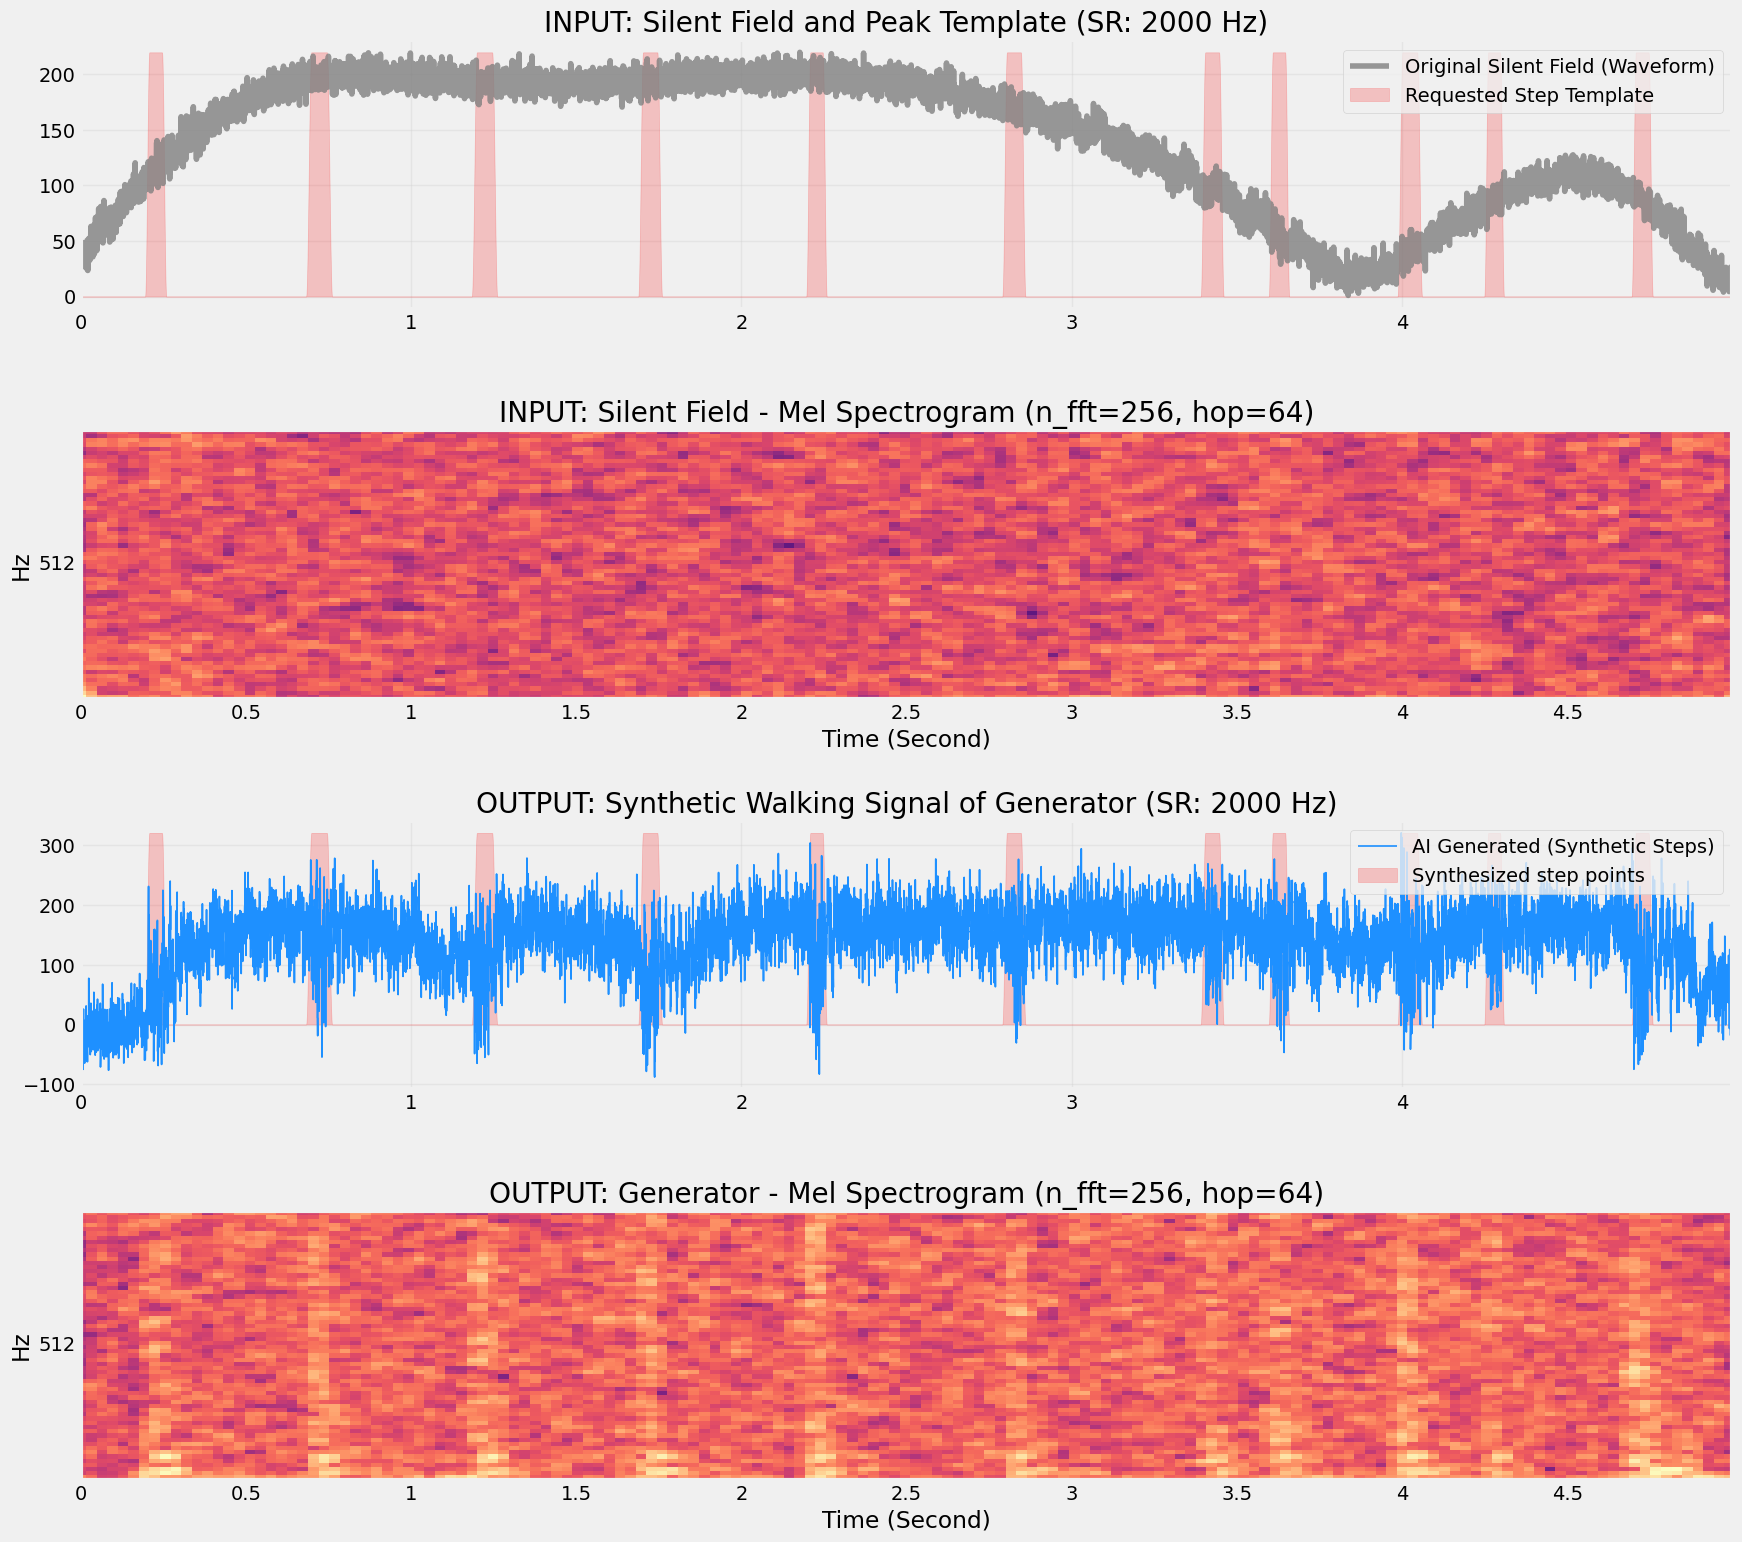

In [1]:
import os
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import h5py
import librosa
import librosa.display
from timesnet_encoder import TimesBlock
from sequences_peaks import _wavelet_filter
from scipy import signal
from diffusion_encoder import build_conditional_unet_1d
from tqdm import tqdm  # +++ YENİ: İlerleme çubuğu için eklendi +++
from utils import setup_gpu
setup_gpu(memory_fraction=0.7)
def _slice_or_pad_signal(s, window_size=5000):
    if len(s) > window_size:
        return s[:window_size]
    elif len(s) < window_size:
        return np.pad(s, (0, window_size - len(s)), mode='constant')
    return s

# --- 1. GİRDİ PARAMETRELERİ (KENDİNE GÖRE DÜZENLE) ---
# MODEL_FOLDER = "20260518-DiffGAN-v4.7.1"
MODEL_FOLDER = "20260622-DiffGAN-v5"
GEN_MODEL_FOLDER = "20260622-DiffGAN-v5"
ENC_WEIGHT_PATH = os.path.join(MODEL_FOLDER, "weights", "encoder_epoch_500.weights.h5")
GEN_WEIGHT_PATH = os.path.join(MODEL_FOLDER, "weights", "diffusion_unet_epoch_500.weights.h5")

SESSİZ_DATA_PATH = "/home/fotas/data/segment/2023.06.04/record_CIFTLIK_SESSIZ_202306040006_30min_raw.bin.hdf5"
CHANNEL = "137" 
WINDOW_START = 0
WINDOW_SIZE = 10000
WINDOW_END = WINDOW_START + WINDOW_SIZE
SAMPLE_RATE = 2000 # DAS cihazının örnekleme frekansı
# ---------------------------------------------------

# --- 2. MODELLERİ İNŞA ET VE AĞIRLIKLARI YÜKLE ---
print("Modeller inşa ediliyor ve ağırlıklar yükleniyor...")
encoder = TimesBlock.build_encoder_v4(window=WINDOW_SIZE, latent_dim=128)
diffusion_unet = build_conditional_unet_1d(window=WINDOW_SIZE, latent_dim=128) # generator ismi diffusion_unet oldu

encoder.load_weights(ENC_WEIGHT_PATH)
diffusion_unet.load_weights(GEN_WEIGHT_PATH)
print("Ağırlıklar başarıyla yüklendi! ✅")

# --- 3. SESSİZ DATAYI OKU ---
print(f"'{SESSİZ_DATA_PATH}' dosyasından {CHANNEL} kanalı okunuyor...")
with h5py.File(SESSİZ_DATA_PATH, "r") as f:
    s = f[CHANNEL][:]["P"]

    if s.dtype.names and "re" in s.dtype.names and "im" in s.dtype.names:
        s_re = s["re"][WINDOW_START:WINDOW_END]
        s_im = s["im"][WINDOW_START:WINDOW_END]
        sessiz_ham = np.hypot(s_re, s_im)
    else:
        sessiz_ham = s[WINDOW_START:WINDOW_END]
        
    sessiz_ham = _slice_or_pad_signal(sessiz_ham, WINDOW_SIZE)

sessiz_ham = sessiz_ham.reshape(1, WINDOW_SIZE, 1).astype(np.float32)

# --- 4. PEAK MASKESİNİ HAZIRLA (Tukey / Flat-Top Şablonlar) ---
peak_mask = np.zeros((1, WINDOW_SIZE, 1), dtype=np.float32)
adim_noktalari = [1500, 3500, 4500, 2500, 500, 5700, 6900, 8100, 8600, 9500, 7300] 

for p in adim_noktalari:
    # 1. Eski kutu maskendeki (140) güçlü genişliği koruyoruz ama biraz doğallık (rastgelelik) katıyoruz.
    width = np.random.randint(120, 160) 
    
    # 2. Eski asimetrik yapını (nokta-120, nokta+20) korumak için merkezi kaydırıyoruz.
    # Adımın vurma anı (peak) sağa daha yakın, ayak sürtünmesi (kuyruk) sola daha uzun.
    start = max(0, p - int(width * 0.85))
    end = min(WINDOW_SIZE, p + int(width * 0.15))
    actual_width = end - start
    
    if actual_width <= 0:
        continue
        
    # 3. Kutu ile Gaussian Karışımı: TUKEY WINDOW
    # alpha=0.4 parametresi şudur: Şablonun %60'ı Kutu gibi dümdüz (1.0), 
    # sağ ve sol %20'lik kısımları ise Gaussian gibi yumuşak sönümlenir.
    tapered_box = signal.windows.tukey(actual_width, alpha=0.4)
    
    # 4. Maksimum genlik KESİNLİKLE 1.0 olmalı (Difüzyon sınırlarını aşmamak için)
    peak_intensity = 1.0 
    tapered_box = tapered_box * peak_intensity
    
    # Maskeye ekle
    peak_mask[0, start:end, 0] = np.maximum(peak_mask[0, start:end, 0], tapered_box)

peak_mask_tf = tf.convert_to_tensor(peak_mask, dtype=tf.float32)

# --- 5. Z-SCORE NORMALİZASYONU ---
mean = np.mean(sessiz_ham, axis=1, keepdims=True)
std = np.std(sessiz_ham, axis=1, keepdims=True) + 1e-8
sessiz_norm = (sessiz_ham - mean) / std

# --- 6. INFERENCE (DİFÜZYON İLE SENTEZLEME) ---
print("Sessiz saha stili analiz ediliyor...")
encoder_input = tf.concat([sessiz_norm, peak_mask], axis=-1)
z_encoded_numpy = encoder.predict(encoder_input, verbose=0)
z_encoded = tf.convert_to_tensor(z_encoded_numpy, dtype=tf.float32)
print("\nDifüzyon Modeli yürüme sinyalini sentezliyor (1000 Adım)...")

# +++ DİFÜZYON TAKVİMİ VE DÖNGÜSÜ +++
T = 1000
betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas)

# Saf beyaz gürültüden (mermer bloğu) başla
x = tf.random.normal(shape=(1, WINDOW_SIZE, 1))

# T'den 0'a doğru adım adım yont
for t in tqdm(reversed(range(T)), total=T, desc="Denoising"):
    t_normalized = tf.ones((1, 1), dtype=tf.float32) * (t / float(T))
    
    # U-Net'ten gürültüyü tahmin etmesini iste
    pred_noise = diffusion_unet([x, t_normalized, z_encoded, peak_mask_tf], training=False)
    
    alpha_t = alphas[t]
    alpha_t_cumprod = alphas_cumprod[t]
    beta_t = betas[t]
    
    # Son adım hariç ekstra gürültü ekle (Langevin Dynamics)
    if t > 0:
        noise = tf.random.normal(shape=tf.shape(x))
    else:
        noise = tf.zeros_like(x)
        
    # DDPM Güncelleme Formülü
    x = (1.0 / np.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / np.sqrt(1.0 - alpha_t_cumprod)) * pred_noise) + np.sqrt(beta_t) * noise

fake_yurume_norm = x.numpy()

# Üretilen veriyi orijinal fiziksel genliğine geri getir
fake_yurume_orijinal = (fake_yurume_norm * std) + mean
print("Sentezleme Başarılı! ✅\n")

# --- 7. VİTRİN / 4 PANELLİ GÖRSELLEŞTİRME ---
sessiz_1d = sessiz_ham[0, :, 0]
fake_1d = fake_yurume_orijinal[0, :, 0]
mask_1d = peak_mask[0, :, 0]

# +++ ZAMAN EKSENİ OLUŞTURMA (SANİYE BAZLI) +++
time_axis = np.arange(WINDOW_SIZE) / SAMPLE_RATE
max_time = time_axis[-1]

# --- SPEKTROGRAM AYARLARI (SR=2000 için optimize edildi) ---
HOP_LENGTH = 64   
N_FFT = 256       
FMIN = 10         
FMAX = 1000       
DB_MIN = -50      

plt.figure(figsize=(18, 16), dpi=100)

# 1. PANEL: Girdi Waveform (HAM)
plt.subplot(4, 1, 1)
plt.plot(time_axis, sessiz_1d, color='gray', alpha=0.8, label="Original Silent Field (Waveform)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(sessiz_1d)), color='red', alpha=0.2, label="Requested Step Template")
plt.xlim([0, max_time]) 
plt.title(f"INPUT: Silent Field and Peak Template (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 2. PANEL: Girdi Mel Spectrogram
ax2 = plt.subplot(4, 1, 2)
S_sessiz = librosa.feature.melspectrogram(y=sessiz_1d, sr=SAMPLE_RATE, n_mels=64, 
                                          n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_sessiz_db = librosa.power_to_db(S_sessiz, ref=np.max)
img_sessiz = librosa.display.specshow(S_sessiz_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                      ax=ax2, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                      cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) 
plt.title(f"INPUT: Silent Field - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Time (Second)")

# 3. PANEL: Çıktı Waveform (HAM)
plt.subplot(4, 1, 3)
plt.plot(time_axis, fake_1d, color='dodgerblue', linewidth=1.2, label="AI Generated (Synthetic Steps)")
plt.fill_between(time_axis, mask_1d * np.max(np.abs(fake_1d)), color='red', alpha=0.2, label="Synthesized step points")
plt.xlim([0, max_time]) 
plt.title(f"OUTPUT: Synthetic Walking Signal of Generator (SR: {SAMPLE_RATE} Hz)")
plt.legend(loc="upper right")
plt.grid(True, alpha=0.3)

# 4. PANEL: Çıktı Mel Spectrogram
ax4 = plt.subplot(4, 1, 4)
S_fake = librosa.feature.melspectrogram(y=fake_1d, sr=SAMPLE_RATE, n_mels=64, 
                                        n_fft=N_FFT, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX)
S_fake_db = librosa.power_to_db(S_fake, ref=np.max)
img_fake = librosa.display.specshow(S_fake_db, x_axis='time', y_axis='mel', sr=SAMPLE_RATE, 
                                    ax=ax4, hop_length=HOP_LENGTH, fmin=FMIN, fmax=FMAX, 
                                    cmap='magma', vmin=DB_MIN, vmax=0)
plt.xlim([0, max_time]) 
plt.title(f"OUTPUT: Generator - Mel Spectrogram (n_fft={N_FFT}, hop={HOP_LENGTH})")
plt.xlabel("Time (Second)")

plt.tight_layout(pad=2.0)
plt.show()

I0000 00:00:1783490090.911870   21901 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


gpus: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Modeller inşa ediliyor ve ağırlıklar yükleniyor...


I0000 00:00:1783490094.596307   21901 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13505 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9
I0000 00:00:1783490094.606782   21901 cuda_executor.cc:522] failed to allocate 13.19GiB (14161018880 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1783490094.606986   21901 cuda_executor.cc:522] failed to allocate 11.87GiB (12744916992 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1783490094.607179   21901 cuda_executor.cc:522] failed to allocate 10.68GiB (11470425088 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory
I0000 00:00:1783490094.607370   21901 cuda_executor.cc:522] failed to allocate 9.61GiB (10323382272 bytes) from device: RESOURCE_EXHAUSTED: : CUDA_ERROR_OUT_OF_MEMORY: out of memory


Ağırlıklar başarıyla yüklendi! ✅

🚀 Sentetik Üretim Başlıyor! Çıktı Dosyası: 20260605-DiffGAN-v4.7.2/synthetic_walking_ciftlik_ch130-150.hdf5

--- İşlenen Kanal: 130 ---


I0000 00:00:1783490096.723601   21982 service.cc:153] XLA service 0x7fecf002fa90 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783490096.723616   21982 service.cc:161]   StreamExecutor [0]: NVIDIA GeForce RTX 4090, Compute Capability 8.9 (Driver: 12.5.0; Runtime: 12.9.0; Toolkit: 12.5.0; DNN: 9.22.0)
I0000 00:00:1783490096.733705   21982 dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1783490096.766594   21982 cuda_dnn.cc:461] Loaded cuDNN version 92200
I0000 00:00:1783490097.570006   21982 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
                                                                     

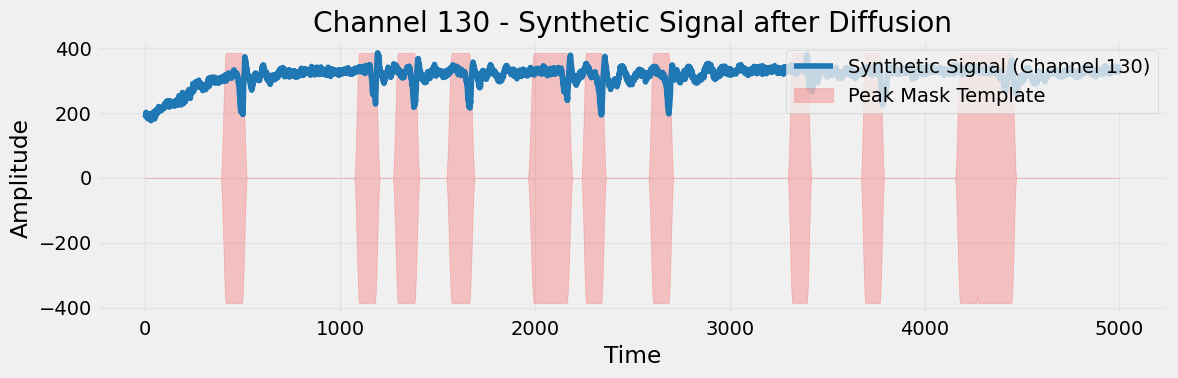


--- İşlenen Kanal: 131 ---


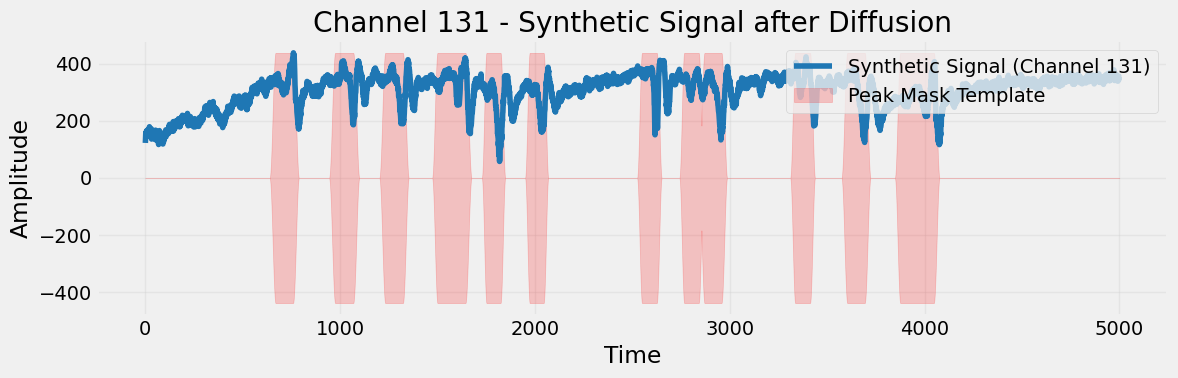


--- İşlenen Kanal: 132 ---


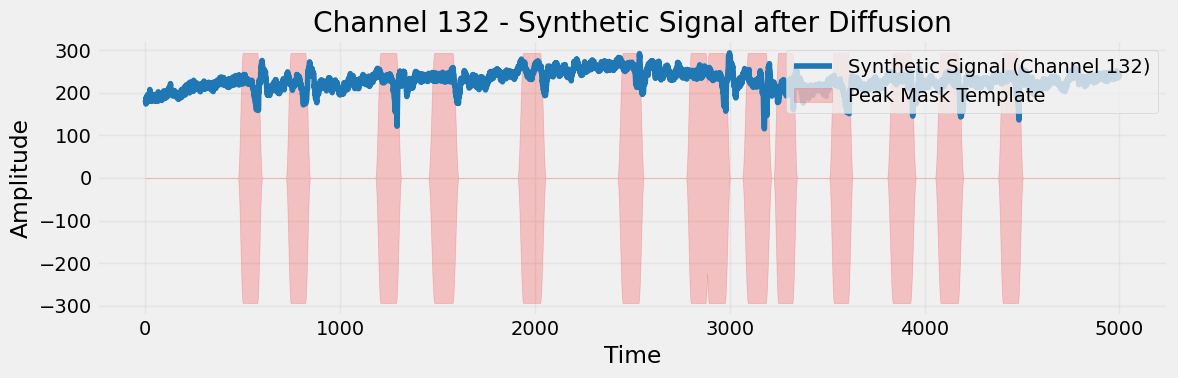


--- İşlenen Kanal: 133 ---


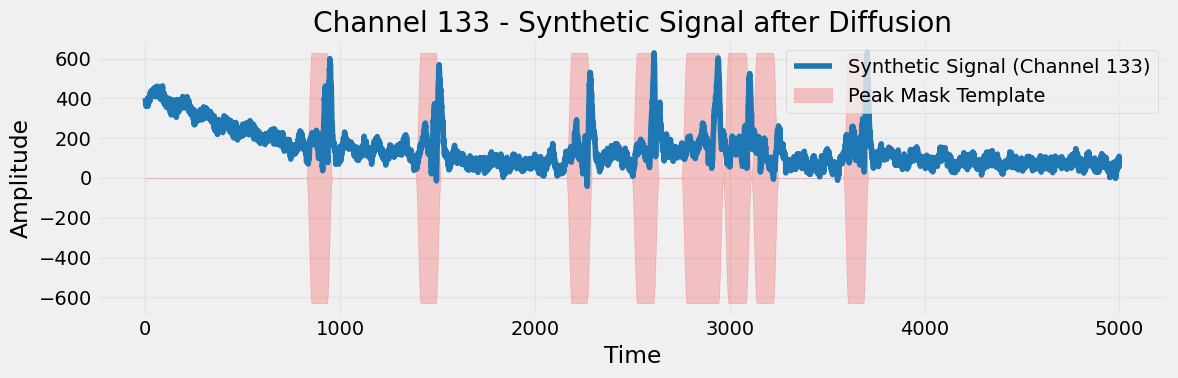


--- İşlenen Kanal: 134 ---


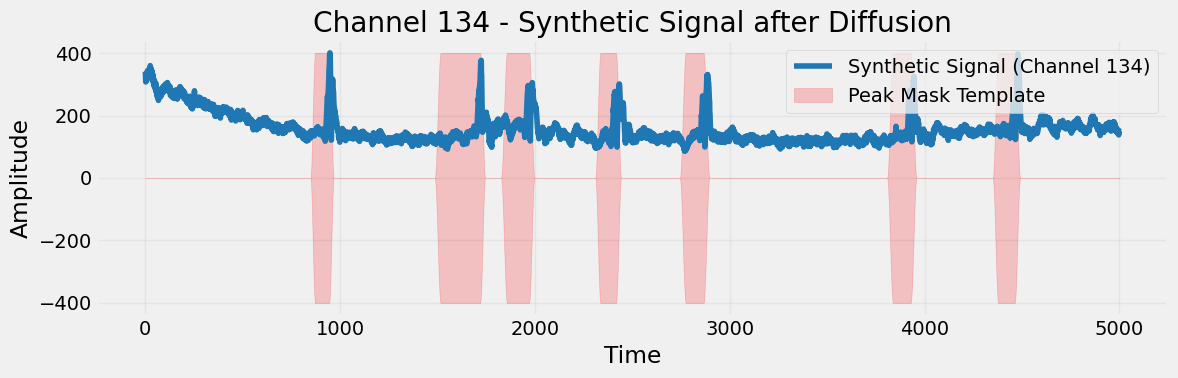


--- İşlenen Kanal: 135 ---


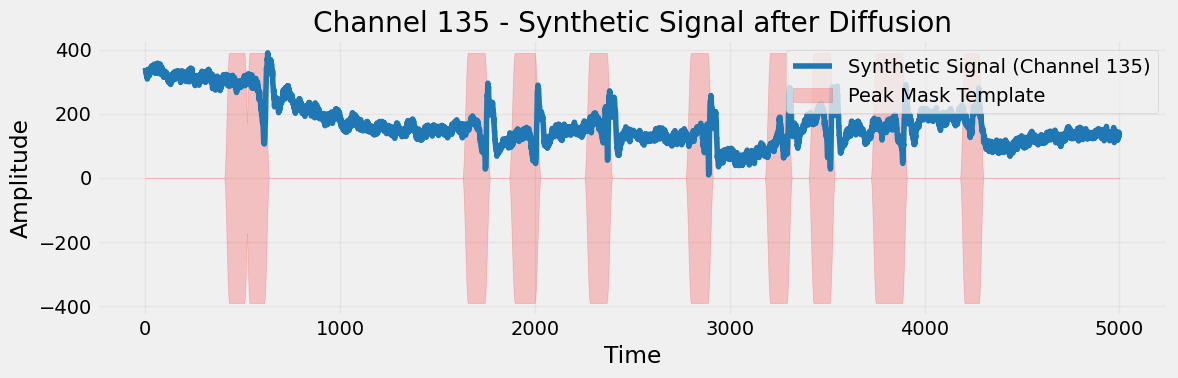


--- İşlenen Kanal: 136 ---


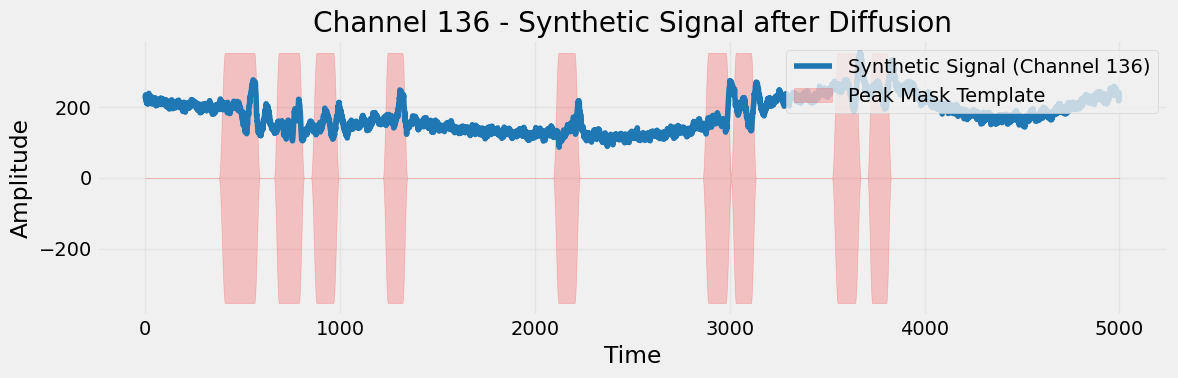


--- İşlenen Kanal: 137 ---


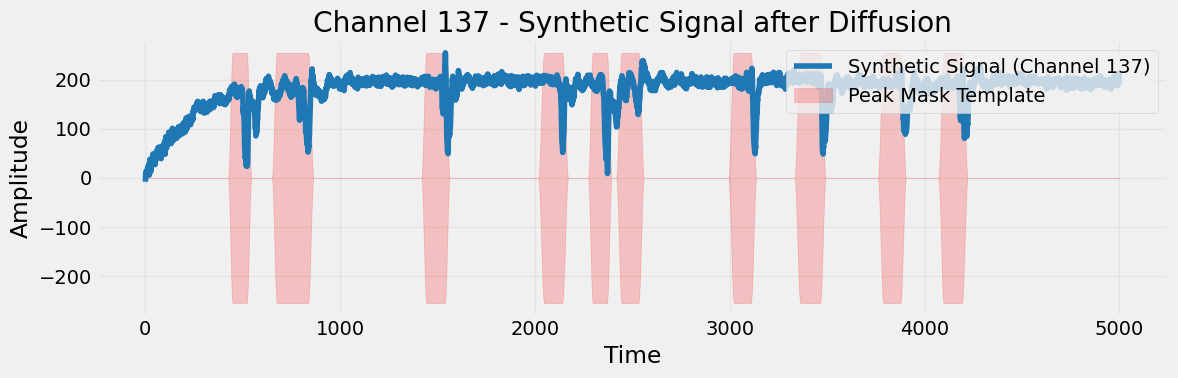


--- İşlenen Kanal: 138 ---


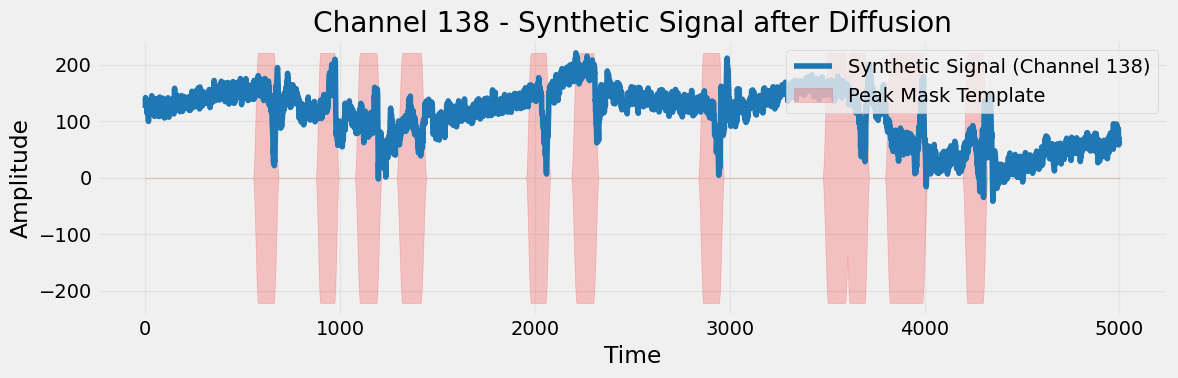


--- İşlenen Kanal: 139 ---


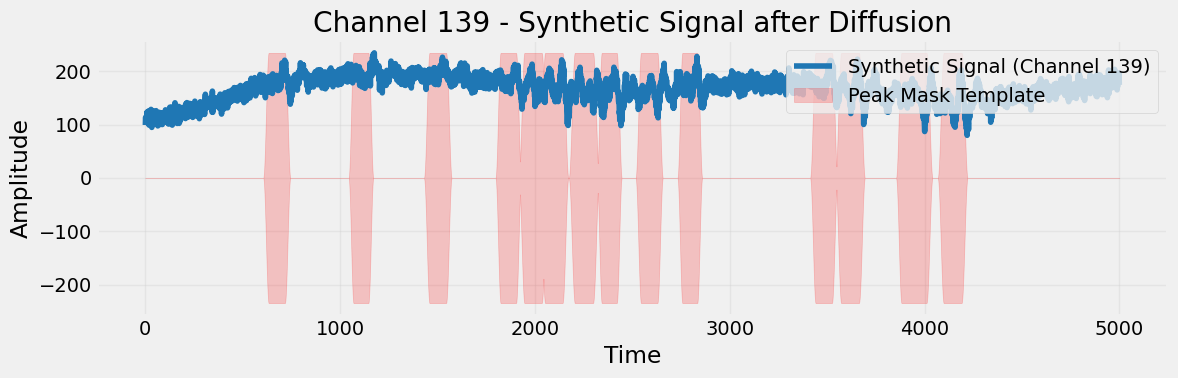


--- İşlenen Kanal: 140 ---


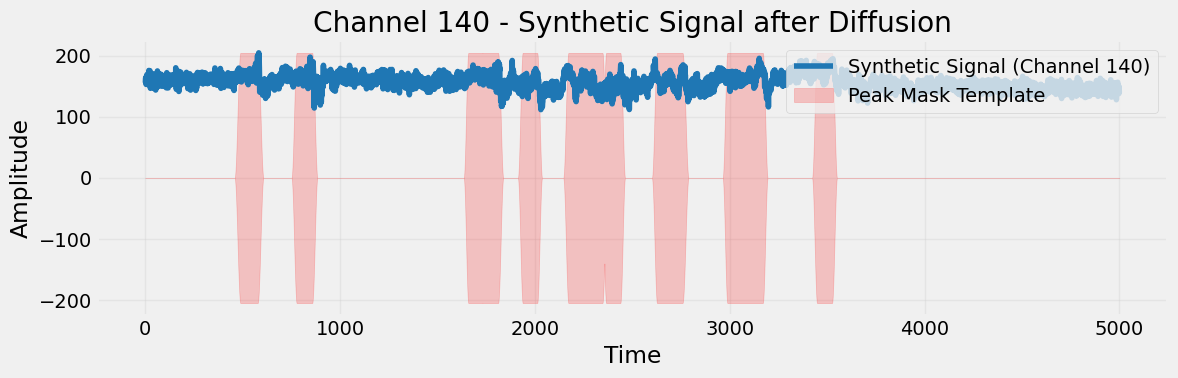


--- İşlenen Kanal: 141 ---


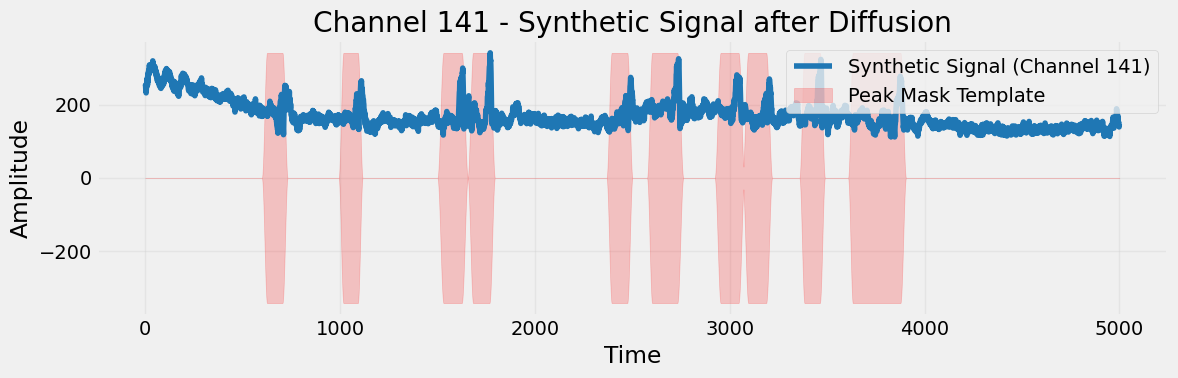


--- İşlenen Kanal: 142 ---


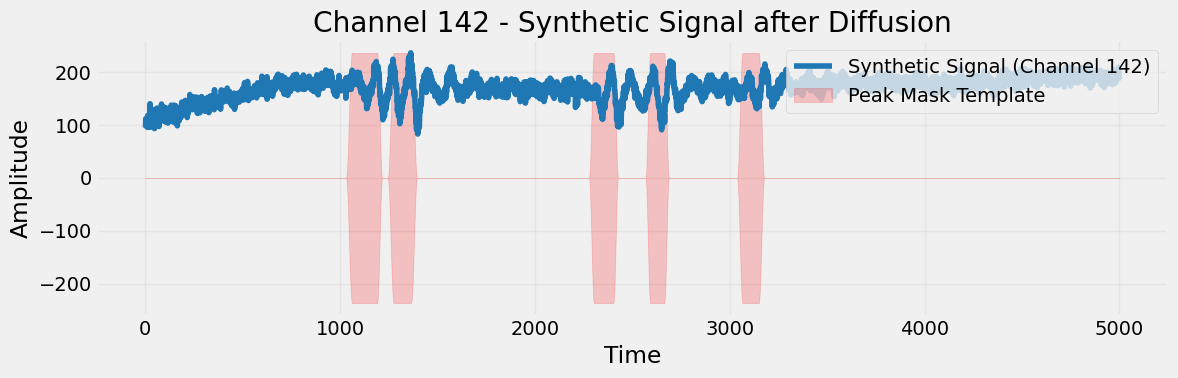


--- İşlenen Kanal: 143 ---


Ch:143 Denoising:  64%|██████▍   | 638/1000 [04:57<02:46,  2.18it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)

                                                                     

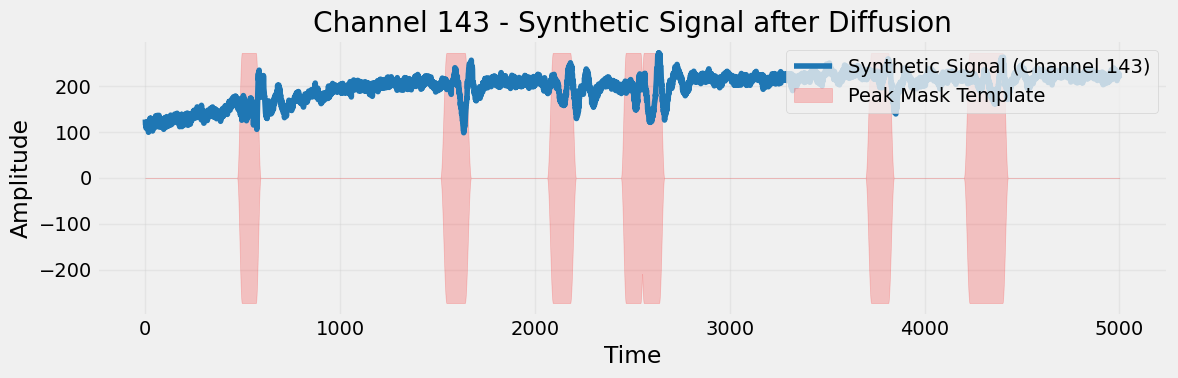


--- İşlenen Kanal: 144 ---


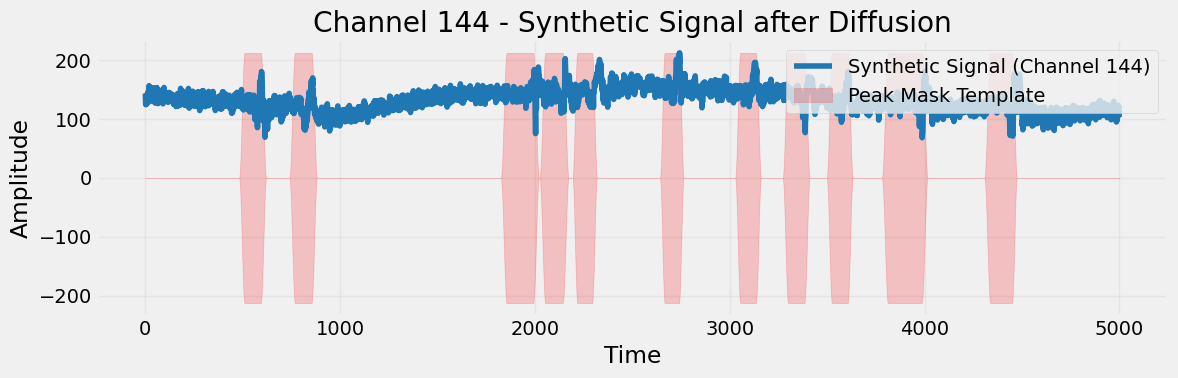


--- İşlenen Kanal: 145 ---


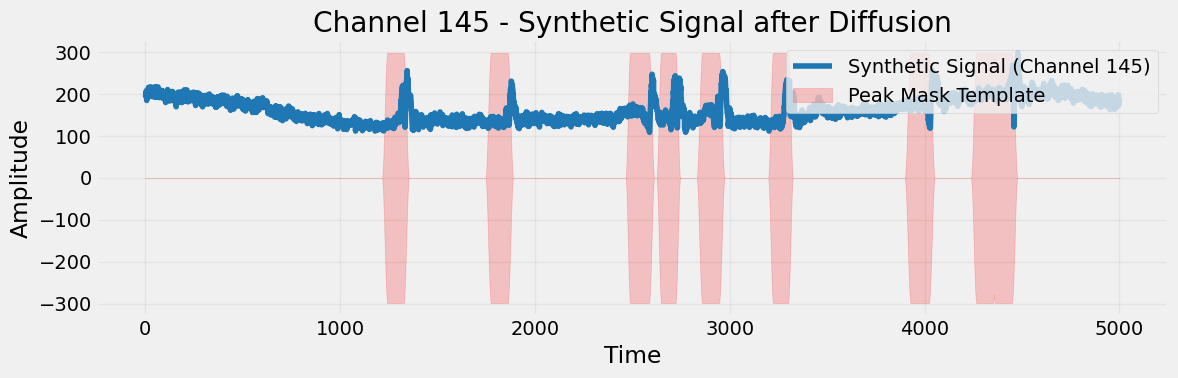


--- İşlenen Kanal: 146 ---


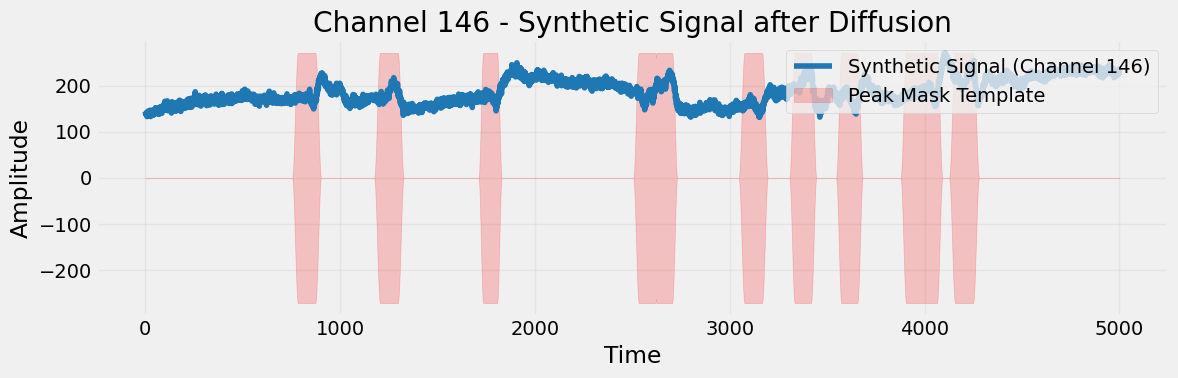


--- İşlenen Kanal: 147 ---


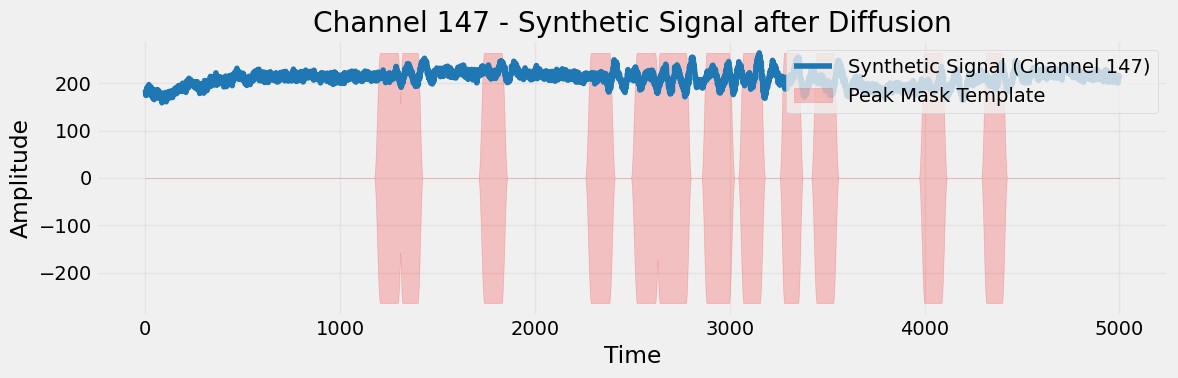


--- İşlenen Kanal: 148 ---


Ch:148 Denoising:  81%|████████  | 806/1000 [06:22<01:31,  2.11it/s]IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [1]:
import os
import numpy as np
import tensorflow as tf
import h5py
import matplotlib.pyplot as plt  # Çizimler için eklendi
from timesnet_encoder import TimesBlock
from diffusion_encoder import build_conditional_unet_1d
from scipy import signal
from tqdm import tqdm
from utils import setup_gpu

setup_gpu(memory_fraction=0.7)

def _slice_or_pad_signal(s, window_size=10000):
    if len(s) > window_size:
        return s[:window_size]
    elif len(s) < window_size:
        return np.pad(s, (0, window_size - len(s)), mode='constant')
    return s

def generate_random_peak_mask(window_size, min_peaks=8, max_peaks=15):
    """Her kanal için rastgele sayılarda ve konumlarda yürüme maskesi üretir."""
    peak_mask = np.zeros((1, window_size, 1), dtype=np.float32)
    
    # Sinyalin başından ve sonundan 500 sample boşluk bırakarak rastgele noktalar seç
    num_peaks = np.random.randint(min_peaks, max_peaks + 1)
    adim_noktalari = np.random.choice(range(500, window_size - 500), size=num_peaks, replace=False)
    adim_noktalari = np.sort(adim_noktalari) # Sıralı olması estetik açıdan iyidir
    for p in adim_noktalari:
        width = np.random.randint(120, 160) 
        
        start = max(0, p - int(width * 0.85))
        end = min(window_size, p + int(width * 0.15))
        actual_width = end - start
        
        if actual_width <= 0:
            continue
            
        tapered_box = signal.windows.tukey(actual_width, alpha=0.4)
        peak_mask[0, start:end, 0] = np.maximum(peak_mask[0, start:end, 0], tapered_box)
    # for p in adim_noktalari:
    #     width = np.random.randint(120, 160) 
        
    #     start = max(0, p - int(width * 0.85))
    #     end = min(window_size, p + int(width * 0.15))
    #     if end > start:
    #         # Tukey vb. yok, dümdüz keskin 1.0 veriyoruz (Square Masking)
    #         peak_mask[0, start:end, 0] = 1.0

    return tf.convert_to_tensor(peak_mask, dtype=tf.float32), peak_mask

# --- 1. GİRDİ VE ÇIKTI PARAMETRELERİ ---
MODEL_FOLDER = "20260605-DiffGAN-v4.7.2"
ENC_WEIGHT_PATH = os.path.join(MODEL_FOLDER, "weights", "encoder_epoch_500.weights.h5")
GEN_WEIGHT_PATH = os.path.join(MODEL_FOLDER, "weights", "diffusion_unet_epoch_500.weights.h5")

# SESSİZ_DATA_PATH = "/home/fotas/data/segment/2023.06.04/record_CIFTLIK_SESSIZ_202306040006_30min_raw.bin.hdf5"
SESSİZ_DATA_PATH = "/tf/start_training/TIMESNET_AUG/record_tpao_sessiz_202607081119_raw.sdf"
OUTPUT_HDF5_PATH = os.path.join(MODEL_FOLDER, "synthetic_walking_tpao_ch500-600.hdf5")

WINDOW_START = 0
WINDOW_SIZE = 5000
WINDOW_END = WINDOW_START + WINDOW_SIZE
T = 1000
CFG_SCALE = 4.0  # +++ CFG Yönlendirme Gücü +++

# --- 2. MODELLERİ İNŞA ET ---
print("Modeller inşa ediliyor ve ağırlıklar yükleniyor...")
encoder = TimesBlock.build_encoder_v4(window=WINDOW_SIZE, latent_dim=128)
diffusion_unet = build_conditional_unet_1d(window=WINDOW_SIZE, latent_dim=128)

encoder.load_weights(ENC_WEIGHT_PATH)
diffusion_unet.load_weights(GEN_WEIGHT_PATH)
print("Ağırlıklar başarıyla yüklendi! ✅")

# DİFÜZYON TAKVİMİ (Sadece 1 kere hesaplanır)
betas = np.linspace(1e-4, 0.02, T, dtype=np.float32)
alphas = 1.0 - betas
alphas_cumprod = np.cumprod(alphas)

# --- 3. BATCH GENERATION (KANALLAR ÜZERİNDE DÖNGÜ) ---
print(f"\n🚀 Sentetik Üretim Başlıyor! Çıktı Dosyası: {OUTPUT_HDF5_PATH}")

with h5py.File(SESSİZ_DATA_PATH, "r") as f_in, h5py.File(OUTPUT_HDF5_PATH, "w") as f_out:
    
    # --- FOTAS HDF5 ZORUNLU METADATA (ÖZNİTELİKLER) ---
    f_out.attrs["polarization"] = 1
    f_out.attrs["port"] = 1
    f_out.attrs["prf"] = 2000
    f_out.attrs["duration"] = WINDOW_SIZE / f_out.attrs["prf"]
    f_out.attrs["channels"] =  101
    f_out.attrs["resolution"] = 0.68        
    f_out.attrs["pulsewidth"] = 25       
    f_out.attrs["sampletype"] = "RealUInt16" 
    
    HDF5_OPTS = {'compression': 'gzip', 'compression_opts': 9, 'shuffle': True}
    
    # 130'dan 150'ye kadar olan kanalları dön (150 dahil)
    for ch in range(500, 601):
        channel_str = str(ch)
        
        if channel_str not in f_in:
            print(f"⚠️ Kanal {channel_str} kaynak dosyada bulunamadı, atlanıyor...")
            continue
            
        print(f"\n--- İşlenen Kanal: {channel_str} ---")
        
        # 3A. Veriyi Oku
        s = f_in[channel_str][:]["P"]
        if s.dtype.names and "re" in s.dtype.names and "im" in s.dtype.names:
            sessiz_ham = np.hypot(s["re"][WINDOW_START:WINDOW_END], s["im"][WINDOW_START:WINDOW_END])
        else:
            sessiz_ham = s[WINDOW_START:WINDOW_END]
            
        sessiz_ham = _slice_or_pad_signal(sessiz_ham, WINDOW_SIZE)
        sessiz_ham = sessiz_ham.reshape(1, WINDOW_SIZE, 1).astype(np.float32)
        
        # 3B. Z-Score Normalizasyonu
        mean = np.mean(sessiz_ham, axis=1, keepdims=True)
        std = np.std(sessiz_ham, axis=1, keepdims=True) + 1e-8
        sessiz_norm = (sessiz_ham - mean) / std
        
        # 3C. Bu Kanala Özel Rastgele Maske Üret
        peak_mask_tf, peak_mask_np = generate_random_peak_mask(WINDOW_SIZE, min_peaks=8, max_peaks=15)
        
        # 3D. Encoder ile Stil Analizi
        encoder_input = tf.concat([sessiz_norm, peak_mask_tf], axis=-1)
        z_encoded_numpy = encoder.predict(encoder_input, verbose=0)
        z_encoded = tf.convert_to_tensor(z_encoded_numpy, dtype=tf.float32)
        
        # 3E. Difüzyon Döngüsü (CFG Destekli)
        x = tf.random.normal(shape=(1, WINDOW_SIZE, 1))
        
        for t in tqdm(reversed(range(T)), total=T, desc=f"Ch:{channel_str} Denoising", leave=False):
            t_normalized = tf.ones((1, 1), dtype=tf.float32) * (t / float(T))
            
            # CFG için hem koşullu hem koşulsuz tahmin
            pred_noise_cond = diffusion_unet([x, t_normalized, z_encoded, peak_mask_tf], training=False)
            pred_noise_uncond = diffusion_unet([x, t_normalized, tf.zeros_like(z_encoded), tf.zeros_like(peak_mask_tf)], training=False)
            
            pred_noise = pred_noise_uncond + CFG_SCALE * (pred_noise_cond - pred_noise_uncond)
            
            alpha_t = alphas[t]
            alpha_t_cumprod = alphas_cumprod[t]
            beta_t = betas[t]
            
            if t > 0:
                noise = tf.random.normal(shape=tf.shape(x))
            else:
                noise = tf.zeros_like(x)
                
            x = (1.0 / np.sqrt(alpha_t)) * (x - ((1.0 - alpha_t) / np.sqrt(1.0 - alpha_t_cumprod)) * pred_noise) + np.sqrt(beta_t) * noise

        # 3F. Üretilen Veriyi Orijinal Genliğine Çevir
        fake_yurume_norm = x.numpy()
        fake_yurume_orijinal = (fake_yurume_norm * std) + mean
        signal_1d = fake_yurume_orijinal[0, :, 0]
        
        # --- ÜRETİMİ GÖRSELLEŞTİRME (PLOT) ---
        plt.figure(figsize=(12, 4))
        plt.plot(signal_1d, label=f"Synthetic Signal (Channel {channel_str})", color='#1f77b4')
        
        # Maskeyi sinyalin genliğine göre ölçeklendirip gölge olarak ekliyoruz
        max_amp = np.max(np.abs(signal_1d))
        mask_1d = peak_mask_np[0, :, 0]
        plt.fill_between(range(WINDOW_SIZE), -max_amp * mask_1d, max_amp * mask_1d, 
                         color='red', alpha=0.2, label='Peak Mask Template')
        
        plt.title(f"Channel {channel_str} - Synthetic Signal after Diffusion")
        plt.xlabel("Time")
        plt.ylabel("Amplitude")
        plt.legend(loc="upper right")
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        # plt.show()  # Çizimi ekranda göster
        save_path = os.path.join(MODEL_FOLDER, f"tpao_synthetic_walking_ch{channel_str}.png")
        plt.savefig(save_path, bbox_inches='tight')
        # 3G. Çıktıları FOTAS Yapısal Dizi Formatında Kaydet
        dt = np.dtype([('P', np.float32)])
        structured_signal = np.zeros(signal_1d.shape, dtype=dt)
        structured_signal['P'] = signal_1d
        
        f_out.create_dataset(channel_str, data=structured_signal, **HDF5_OPTS)

    # 4. Döngü bittikten sonra Labels'ı BOŞ olarak kaydet
    f_out.create_dataset('labels', shape=(0, 6), dtype='u4', **HDF5_OPTS)

print(f"\n🎉 Tüm kanallar başarıyla üretildi, görselleştirildi ve FOTAS formatında kaydedildi!")
print(f"📁 Dosya konumu: {OUTPUT_HDF5_PATH}")

In [5]:
import h5py
import numpy as np

# --- PARAMETRELER ---
YENI_DOSYA = MODEL_FOLDER + "/synthetic_walking.hdf5"  # Yeni formatta kaydedilecek dosyanın yolu

PRF_VALUE = 2000       # Kendi PRF değerinizi girin
DURATION_VALUE = 150.0  # Kendi süre değerinizi girin
# --------------------

all_labels = []

with h5py.File(OUTPUT_HDF5_PATH, "r") as f_in, h5py.File(YENI_DOSYA, "w") as f_out:
    
    # Eski dosyadaki '_signal' ile biten tüm kanalları bul (Kanal sayısını/uzunluğunu öğrenmek için)
    channel_keys = [k.replace('_signal', '') for k in f_in.keys() if k.endswith('_signal')]
    
    # Veri uzunluğunu (frameLength) ilk kanaldan öğren
    if channel_keys:
        sample_signal = f_in[f"{channel_keys[0]}_signal"][:]
        frame_length = len(sample_signal)
    else:
        frame_length = 0

    # 1. Okuma sınıfının beklediği ZORUNLU METADATA (Attributes)
    f_out.attrs["polarization"] = 1
    f_out.attrs["port"] = 1
    f_out.attrs["prf"] = 2000
    f_out.attrs["duration"] = 150.0
    f_out.attrs["channels"] = 11  # Sizin segment metodunuzda frameLength channels'a atanıyor
    f_out.attrs["resolution"] = 0.68        # Örnek değer, kendi sisteminize göre değiştirin
    f_out.attrs["pulsewidth"] = 100         # Örnek değer, kendi sisteminize göre değiştirin
    
    # Karmaşık sayı (re, im) formatına girmemek için Real modunda tanıtıyoruz:
    f_out.attrs["sampletype"] = "RealUInt16" 
    
    # FotasSegmentFile'ın segment metodundaki sıkıştırma ayarları
    HDF5_OPTS = {'compression': 'gzip', 'compression_opts': 9, 'shuffle': True}

    for ch_str in channel_keys:
        ch_int = int(ch_str)
        print(f"Düzenleniyor: Kanal {ch_str}")
        
        # 2. Sinyali yapısal diziye (Structured Array 'P') çevir
        signal_1d = f_in[f"{ch_str}_signal"][:]
        
        # dtype float32 yapıyoruz, okuma kodunuz np.zeros(..., np.float32) kullandığı için sorunsuz eşleşecek
        dt = np.dtype([('P', np.float32)])
        structured_signal = np.zeros(signal_1d.shape, dtype=dt)
        structured_signal['P'] = signal_1d
        
        # Yeni dosyaya sadece kanal numarası adıyla kaydet (Örn: '130')
        f_out.create_dataset(ch_str, data=structured_signal, **HDF5_OPTS)
        
        # 3. Maskeyi etiketlere (labels) dönüştür
        mask_key = f"{ch_str}_mask"
        if mask_key in f_in:
            mask_1d = f_in[mask_key][:]
            is_peak = mask_1d > 0.5 
            diffs = np.diff(is_peak.astype(int))
            
            starts = np.where(diffs == 1)[0] + 1
            if is_peak[0]: 
                starts = np.insert(starts, 0, 0)
                
            ends = np.where(diffs == -1)[0] + 1
            if is_peak[-1]:
                ends = np.append(ends, len(mask_1d))
                
            for w_start, w_end in zip(starts, ends):
                # Format: [w_start, w_end, ch_start, ch_end, _, _]
                all_labels.append([w_start, w_end, ch_int, ch_int, 0, 0])
                
    # 4. Tüm etiketleri 'u4' (uint32) formatında tek bir veri seti olarak kaydet
    if all_labels:
        f_out.create_dataset('labels', data=np.array(all_labels, dtype='u4'), **HDF5_OPTS)
    else:
        f_out.create_dataset('labels', shape=(0, 6), dtype='u4', **HDF5_OPTS)

print("\n✅ Dönüştürme işlemi tamamlandı. FotasSegmentFile ile okuyabilirsiniz.")

Düzenleniyor: Kanal 130
Düzenleniyor: Kanal 131
Düzenleniyor: Kanal 132
Düzenleniyor: Kanal 133
Düzenleniyor: Kanal 134
Düzenleniyor: Kanal 135
Düzenleniyor: Kanal 136
Düzenleniyor: Kanal 137
Düzenleniyor: Kanal 138
Düzenleniyor: Kanal 139
Düzenleniyor: Kanal 140
Düzenleniyor: Kanal 141
Düzenleniyor: Kanal 142
Düzenleniyor: Kanal 143
Düzenleniyor: Kanal 144
Düzenleniyor: Kanal 145
Düzenleniyor: Kanal 146
Düzenleniyor: Kanal 147
Düzenleniyor: Kanal 148
Düzenleniyor: Kanal 149
Düzenleniyor: Kanal 150

✅ Dönüştürme işlemi tamamlandı. FotasSegmentFile ile okuyabilirsiniz.
